<details>
   <summary><b>Table of Contents</b></summary>

   - [1. Review Data](#1-review-data)
   - [2. Data Visualization](#2-data-visualization)
     - [2.1. Eploratory (Univariate Analysis)](#21-eploratory-univariate-analysis)
       - [a. Numerical Features](#a-numerical-features)
       - [b. Categorical Features](#b-categorical-features)
     - [2.2. Analysis (Bivariate Analysis)](#22-analysis-bivariate-analysis)
       - [a. Job-related group](#a-job-related-group-job_simplified-seniority-industry-sector)
       - [b. Company-related group](#b-company-related-group-company-name-size-age-type-of-ownership-rating-rating-category-revenue)
       - [c. Skill-related group](#c-skill-related-group-python_yn-spark-aws_yn-excel_yn-tableau_yn-sql_yn)
       - [d. Location-related group](#d-location-related-group-job_state-headquarters-location-same_state)
   - [3. Feature Selection](#3-feature-selection)
     - [3.1. Correlation Matrix](#31-correlation-matrix)
     - [3.2. ANOVA Analysis](#32-anova-analysis)
     - [3.3. Save features](#33-save-features)
</details>

In [ ]:
import warnings
import itertools

import numpy             as np
import pandas            as pd
import scipy.stats       as stats
import seaborn           as sns
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Configure pandas to display all columns
pd.set_option('display.max_columns', None)

# Set Seaborn theme for visualization
sns.set_theme(style='whitegrid')

## **1. Review Data**

---

In [2]:
df = pd.read_csv('../data/data_EDA.csv')
df.head()

,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,job_simplified,seniority,Min Salary,Max Salary,Average Salary,Python_yn,Spark,AWS_yn,Excel_yn,Tableau_yn,SQL_yn,Rating Category,job_state,same_state,Age
0,3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),data scientist,Other,53000,91000,72000.0,1,0,0,1,1,0,Medium Rating,NM,0,50
1,3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+ employees,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),data scientist,Other,63000,112000,87500.0,1,0,0,0,0,0,Medium Rating,MD,0,39
2,4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,Company - Private,Security Services,Business Services,$100 to $500 million (USD),data scientist,Other,80000,90000,85000.0,1,1,0,1,0,1,High Rating,FL,1,13
3,3.8,PNNL,"Richland, WA","Richland, WA",1001 to 5000 employees,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),data scientist,Other,56000,97000,76500.0,1,0,0,0,0,0,Medium Rating,WA,1,58
4,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,Company - Private,Advertising & Marketing,Business Services,Unknown,data scientist,Other,86000,143000,114500.0,1,0,0,1,0,1,Low Rating,NY,1,25


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             742 non-null    float64
 1   Company Name       742 non-null    object 
 2   Location           742 non-null    object 
 3   Headquarters       742 non-null    object 
 4   Size               742 non-null    object 
 5   Type of ownership  742 non-null    object 
 6   Industry           742 non-null    object 
 7   Sector             742 non-null    object 
 8   Revenue            742 non-null    object 
 9   job_simplified     742 non-null    object 
 10  seniority          742 non-null    object 
 11  Min Salary         742 non-null    int64  
 12  Max Salary         742 non-null    int64  
 13  Average Salary     742 non-null    float64
 14  Python_yn          742 non-null    int64  
 15  Spark              742 non-null    int64  
 16  AWS_yn             742 non

In [4]:
df.describe()

,Rating,Min Salary,Max Salary,Average Salary,Python_yn,Spark,AWS_yn,Excel_yn,Tableau_yn,SQL_yn,same_state,Age
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.633693,74771.752022,128226.900270,101499.326146,0.528302,0.225067,0.237197,0.522911,0.199461,0.512129,0.557951,49.389488
std,0.720715,30926.957646,45110.814223,37463.032093,0.499535,0.417908,0.425651,0.499812,0.399865,0.500190,0.496965,53.962906
min,0.000000,15000.000000,16000.000000,15500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,3.300000,52000.000000,96000.000000,73500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000
50%,3.700000,69500.000000,124000.000000,97500.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,27.000000
75%,4.000000,91000.000000,155000.000000,122500.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,62.000000
max,5.000000,202000.000000,306000.000000,254000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,279.000000


## **2. Data Visualization**

---

In [5]:
# Customize
font_tit = {'fontsize': 14, 'fontweight': 'bold'}
font_ax  = {'fontsize': 12, 'fontweight': 'bold', 'style': 'italic'}
font_txt = {'fontsize': 10, 'fontweight': 'bold', 'color': 'black'}
cmap10   = ['#00429d', '#3e67ae', '#618fbf', '#85b7ce', '#b1dfdb', '#ffcab9', '#fd9291', '#e75d6f', '#c52a52', '#93003a']

### **2.1. Eploratory (Univariate Analysis)**

#### ***a. Numerical Features***

In [6]:
continuous_cols = ['Min Salary', 'Max Salary', 'Average Salary', 'Rating', 'Age']
discrete_cols   = ['Python_yn', 'Spark', 'AWS_yn', 'Excel_yn', 'Tableau_yn', 'SQL_yn', 'same_state']

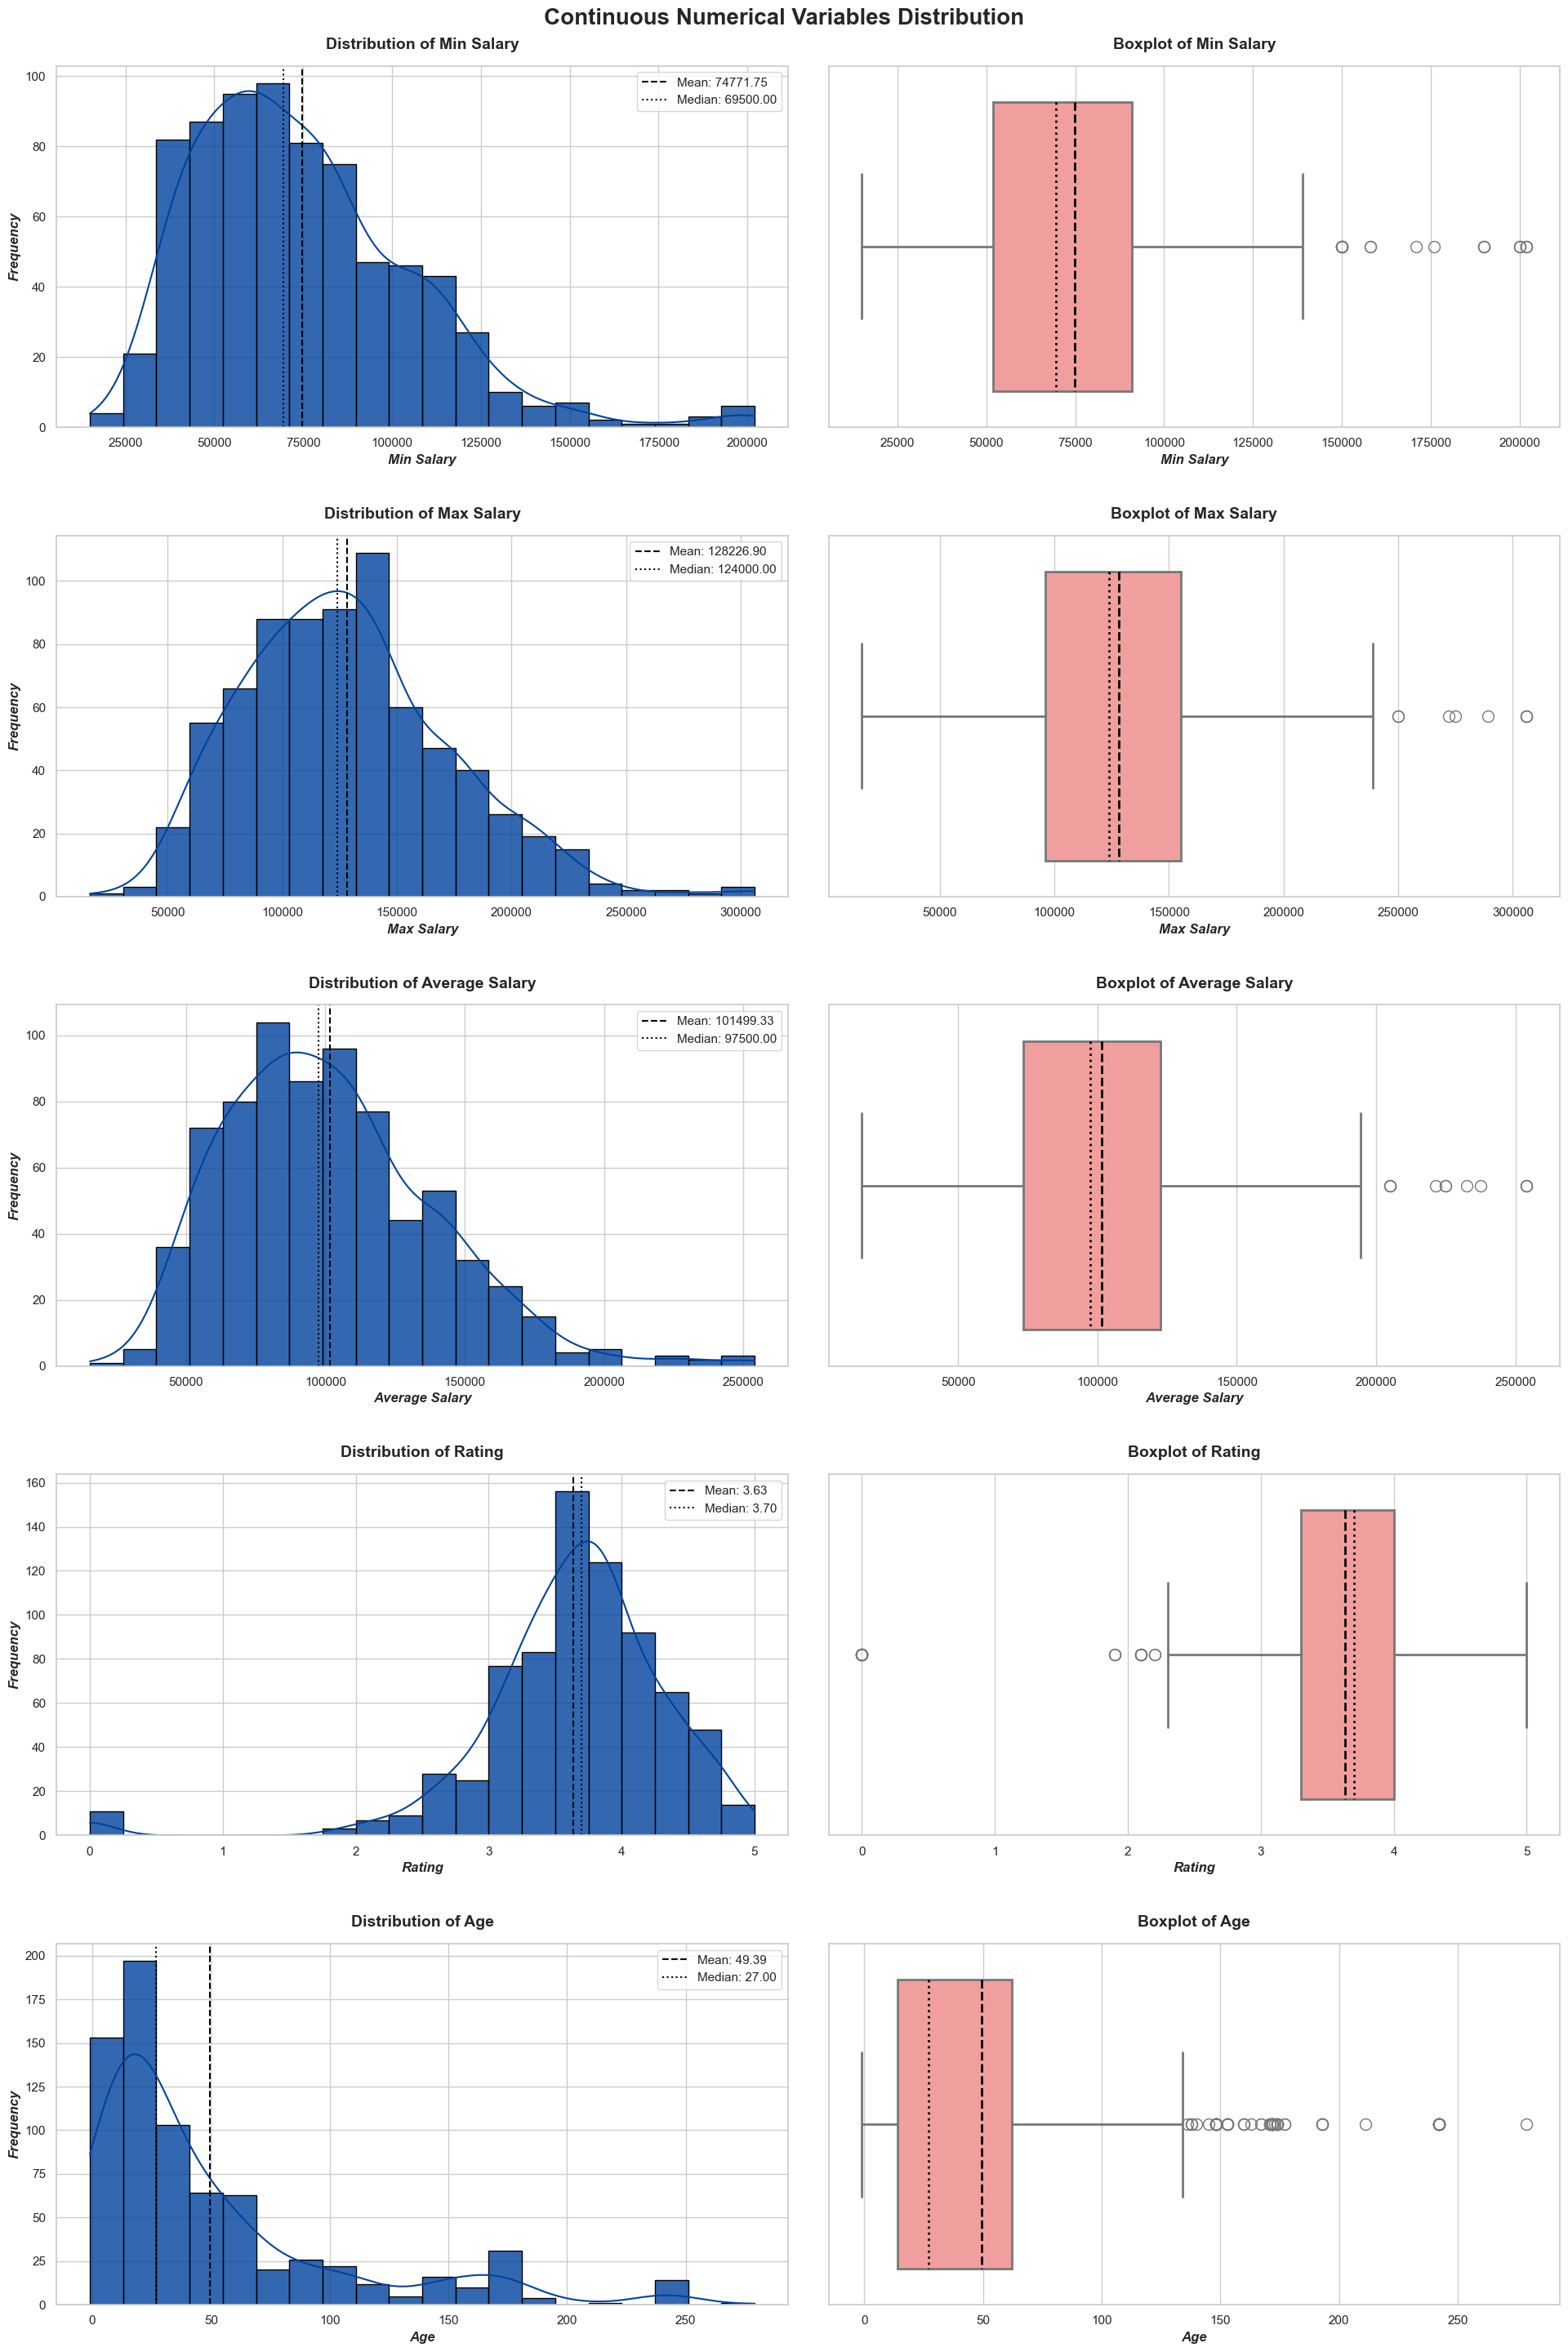

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(20, 30))

for idx, col in enumerate(continuous_cols):
    sns.histplot(df[col], ax=axes[idx, 0], kde=True, bins=20, color=cmap10[0], alpha=0.8, edgecolor='black')

    mean_val   = df[col].mean()
    median_val = df[col].median()
    axes[idx, 0].axvline(mean_val  , color='black', linestyle='--'    , label=f'Mean: {mean_val:.2f}')
    axes[idx, 0].axvline(median_val, color='black', linestyle='dotted', label=f'Median: {median_val:.2f}')
    axes[idx, 0].legend()

    axes[idx, 0].set_title(f'Distribution of {col}', fontdict=font_tit, pad=15)
    axes[idx, 0].set_xlabel(col, fontdict=font_ax)
    axes[idx, 0].set_ylabel('Frequency', fontdict=font_ax)

    sns.boxplot(data=df, x=col, ax=axes[idx, 1], color=cmap10[6],
                fliersize=10, linewidth=2, showmeans=True, meanline=True,
                meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 2},
                medianprops={'color': 'black', 'linestyle': 'dotted', 'linewidth': 2})

    axes[idx, 1].set_title(f'Boxplot of {col}', fontdict=font_tit, pad=15)
    axes[idx, 1].set_xlabel(col, fontdict=font_ax)

plt.suptitle('Continuous Numerical Variables Distribution', y=0.97, fontsize=20, fontweight='bold')
plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> - `Min Salary`: Slightly right-skewed, mean (74,771.75) and median (69,500) are close. Most values range from 50,000–100,000, with high outliers above 150,000.  
>  
> - `Max Salary`: Slightly right-skewed, mean (128,226.90) and median (124,000) are similar. Main range is 80,000–150,000, with outliers above 200,000.  
>  
> - `Average Salary`: Similar to Min/Max Salary, slightly right-skewed. Mean (101,499.33) and median (97,500) show balance, but high outliers exist above 200,000.  
>  
> - `Rating`: Near-normal distribution, slightly left-skewed. Mean (3.63) and median (3.70) indicate concentration around 3–4, with minor outliers.  
>  
> - `Company Age`: Highly right-skewed, with mean (49.39) much higher than median (27.00). Most companies are younger, but extreme outliers exist above 100 years.  

> **Summary**: Salary features are balanced but have high outliers. Rating is mostly within 3–4, while company age is highly skewed with extreme values.  

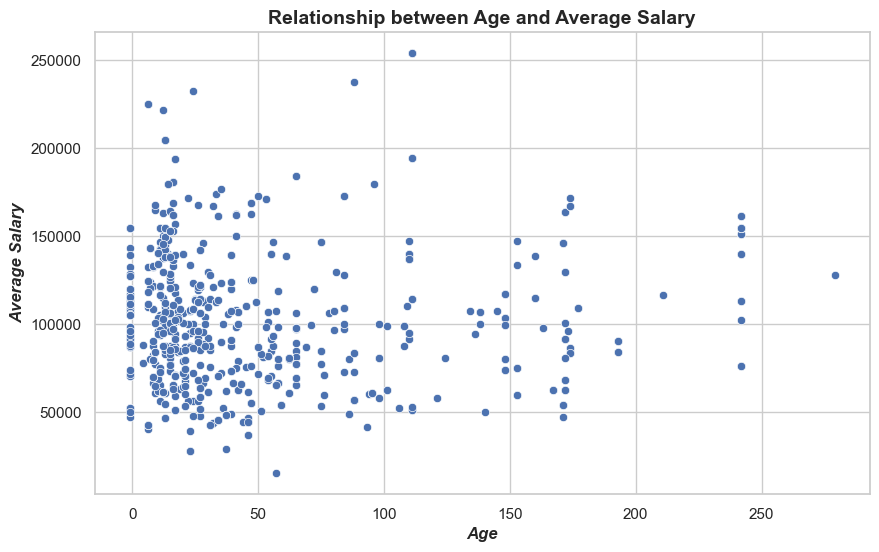

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Average Salary', data=df)
plt.title('Relationship between Age and Average Salary', fontdict=font_tit)
plt.xlabel('Age', fontdict=font_ax)
plt.ylabel('Average Salary', fontdict=font_ax)
plt.show()

> **Observations**:  
>  
> - Young Companies (0–50 years): Most fall in this range, salaries between 50,000–150,000 USD, some exceeding 200,000 USD.  
>  
> - Older Companies (>50 years): Some exceed 100+ years, salaries widely dispersed.  
>  
> - High Salaries: No clear trend; both young and old companies can pay high salaries.  
>  
> - Data Spread: No strong correlation between company age and salary.  

> **Summary**: No clear linear relationship between company age and salary. Young companies dominate with stable salary trends. Older companies may require further validation for anomalies.  

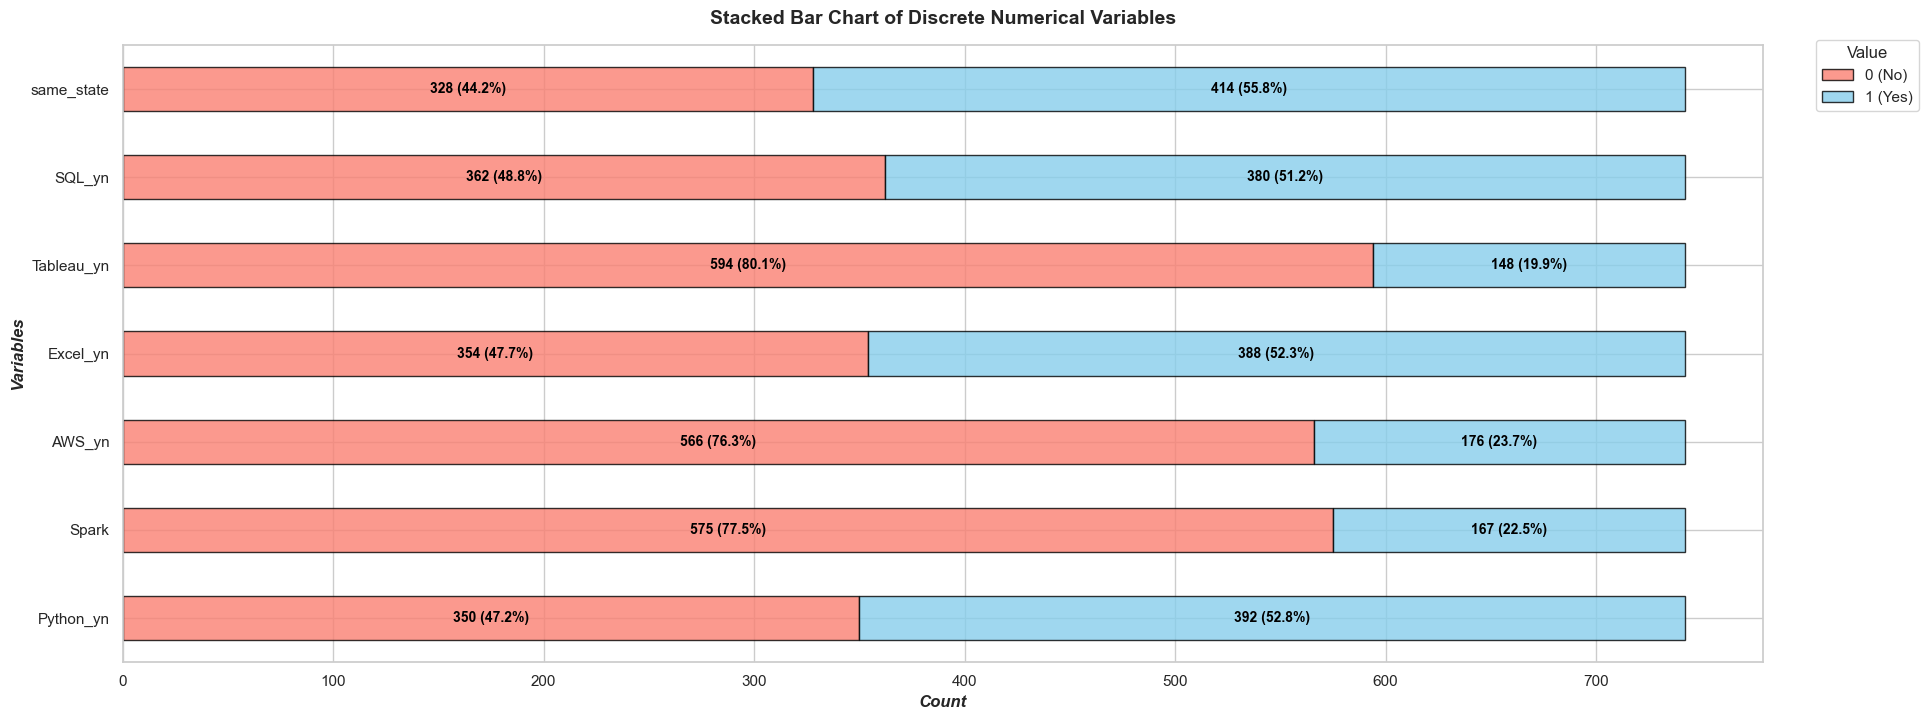

In [9]:
counts         = df[discrete_cols].apply(pd.Series.value_counts).T
counts.columns = ['Count 0', 'Count 1']
percentages    = counts.div(counts.sum(axis=1), axis=0) * 100

_, ax = plt.subplots(figsize=(20, 8))
counts.plot(kind='barh', stacked=True, ax=ax, alpha=0.8, edgecolor='black', color=['salmon', 'skyblue'])

for i, (pct_0, pct_1, cnt_0, cnt_1) in enumerate(zip(percentages['Count 0'], percentages['Count 1'], counts['Count 0'], counts['Count 1'])):
    ax.text(cnt_0 / 2, i        , f'{cnt_0} ({pct_0:.1f}%)', va='center', ha='center', fontdict=font_txt)
    ax.text(cnt_0 + cnt_1 / 2, i, f'{cnt_1} ({pct_1:.1f}%)', va='center', ha='center', fontdict=font_txt)

plt.title('Stacked Bar Chart of Discrete Numerical Variables', fontdict=font_tit, pad=15)
plt.xlabel('Count', fontdict=font_ax)
plt.ylabel('Variables', fontdict=font_ax)
plt.legend(['0 (No)', '1 (Yes)'], title='Value', loc='upper right', bbox_to_anchor=(1.1, 1.02))

plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> - `same_state`: Majority **Yes (55.8%)**, indicating most employees work in the same state.  
>  
> - `SQL_yn`: Nearly balanced **(Yes: 51.2%)**, showing SQL proficiency is common.  
>  
> - `Tableau_yn`: Mostly **No (80.1%)**, indicating low Tableau proficiency.  
>  
> - `Excel_yn`: Slightly more **Yes (52.3%)**, showing Excel is widely used.  
>  
> - `AWS_yn`: Mostly **No (76.3%)**, suggesting AWS skills are less common.  
>  
> - `Spark`: Mostly **No (77.5%)**, similar to AWS in low adoption.  
>  
> - `Python_yn`: Slightly more **Yes (52.8%)**, indicating Python is relatively common.  

> **Summaries**:   
>  
> - Common skills: Python, Excel, SQL (>50% Yes).  
>  
> - Less common skills: Tableau, AWS, Spark (<50% Yes).  
>  
> - Location: Over half of employees work in the same state.  

#### ***b. Categorical Features***

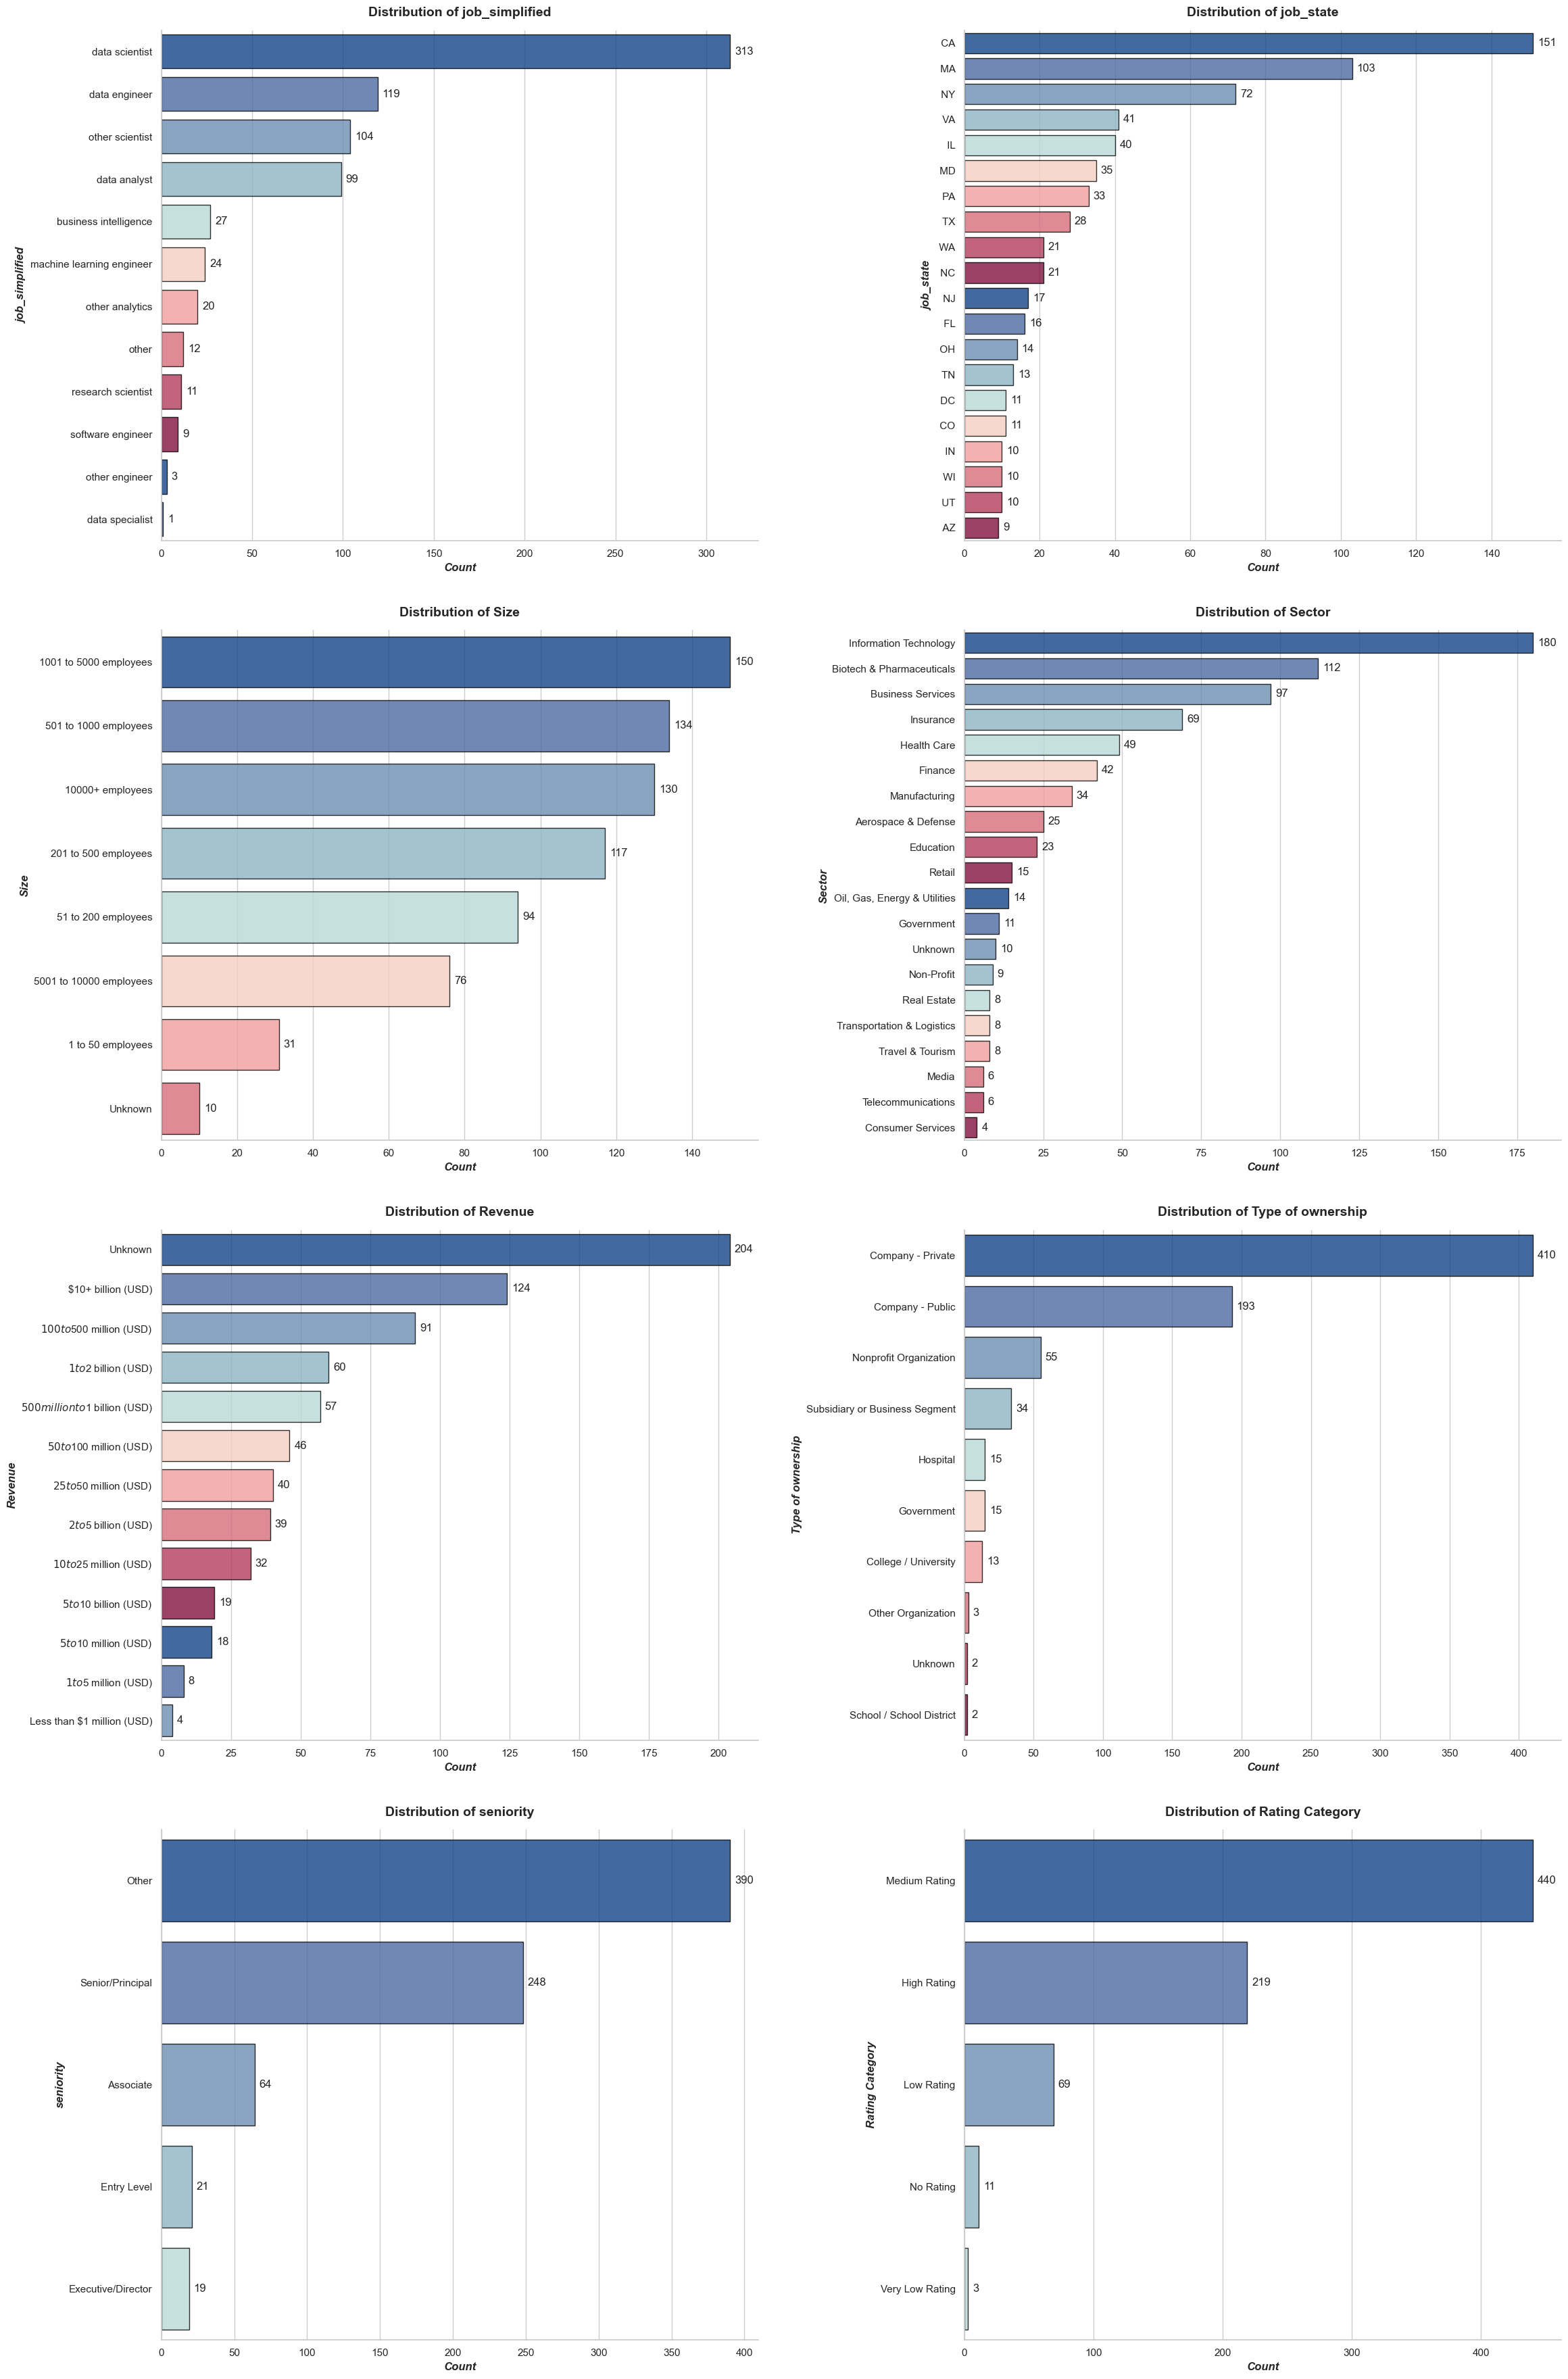

In [10]:
object_columns = ['job_simplified', 'job_state', 'Size', 'Sector', 'Revenue',
                  'Type of ownership', 'seniority', 'Rating Category']
fig, axes = plt.subplots(4, 2, figsize=(24, 36))

for col, ax in zip(object_columns, axes.ravel()):
    value_counts = df[col].value_counts().head(20)

    sns.barplot(y=value_counts.index, x=value_counts.values, ax=ax, palette=cmap10, alpha=0.8, edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontdict=font_tit, pad=15)
    ax.set_xlabel('Count', fontdict=font_ax)
    ax.set_ylabel(col, fontdict=font_ax)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=5)

sns.despine(top=True, right=True)
plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> - Job Role: **Data Scientist** is the most common (313), followed by **Data Engineer** (119) and **Data Analyst** (99).  
>  
> - Job State: **California (151)** leads, followed by **Massachusetts (103)** and **New York (72)**.  
>  
> - Company Size: Most companies have **1001-5000 employees (150)**, with large corporations (**10,000+ employees**) also significant.  
>  
> - Sector: **IT (180)** dominates, followed by **Biotech & Pharma (112)** and **Business Services (97)**.  
>  
> - Revenue: **Undisclosed revenue (204)** is most common, with **$10B+ revenue companies (124)** also significant.  
>  
> - Ownership Type: **Private companies (410)** dominate, followed by **Public companies (193)**.  
>  
> - Seniority: **Senior/Principal (248)** is the most common defined level, while **Executive/Director (2)** is rare.  
>  
> - Company Rating: **Medium rating (440)** is the majority, with **High rating (219)** significantly present.   

> **Summaries**:  
>  
> - **Data Scientist** is the most sought-after role, concentrated in major states like **CA and MA**.   
>  
> - **Large companies** and **tech-related sectors** dominate the market.  
>  
> - Most companies are **privately owned** and **rated medium to high**.  
>  
> - Senior roles are in high demand, reflecting a need for experienced professionals.  

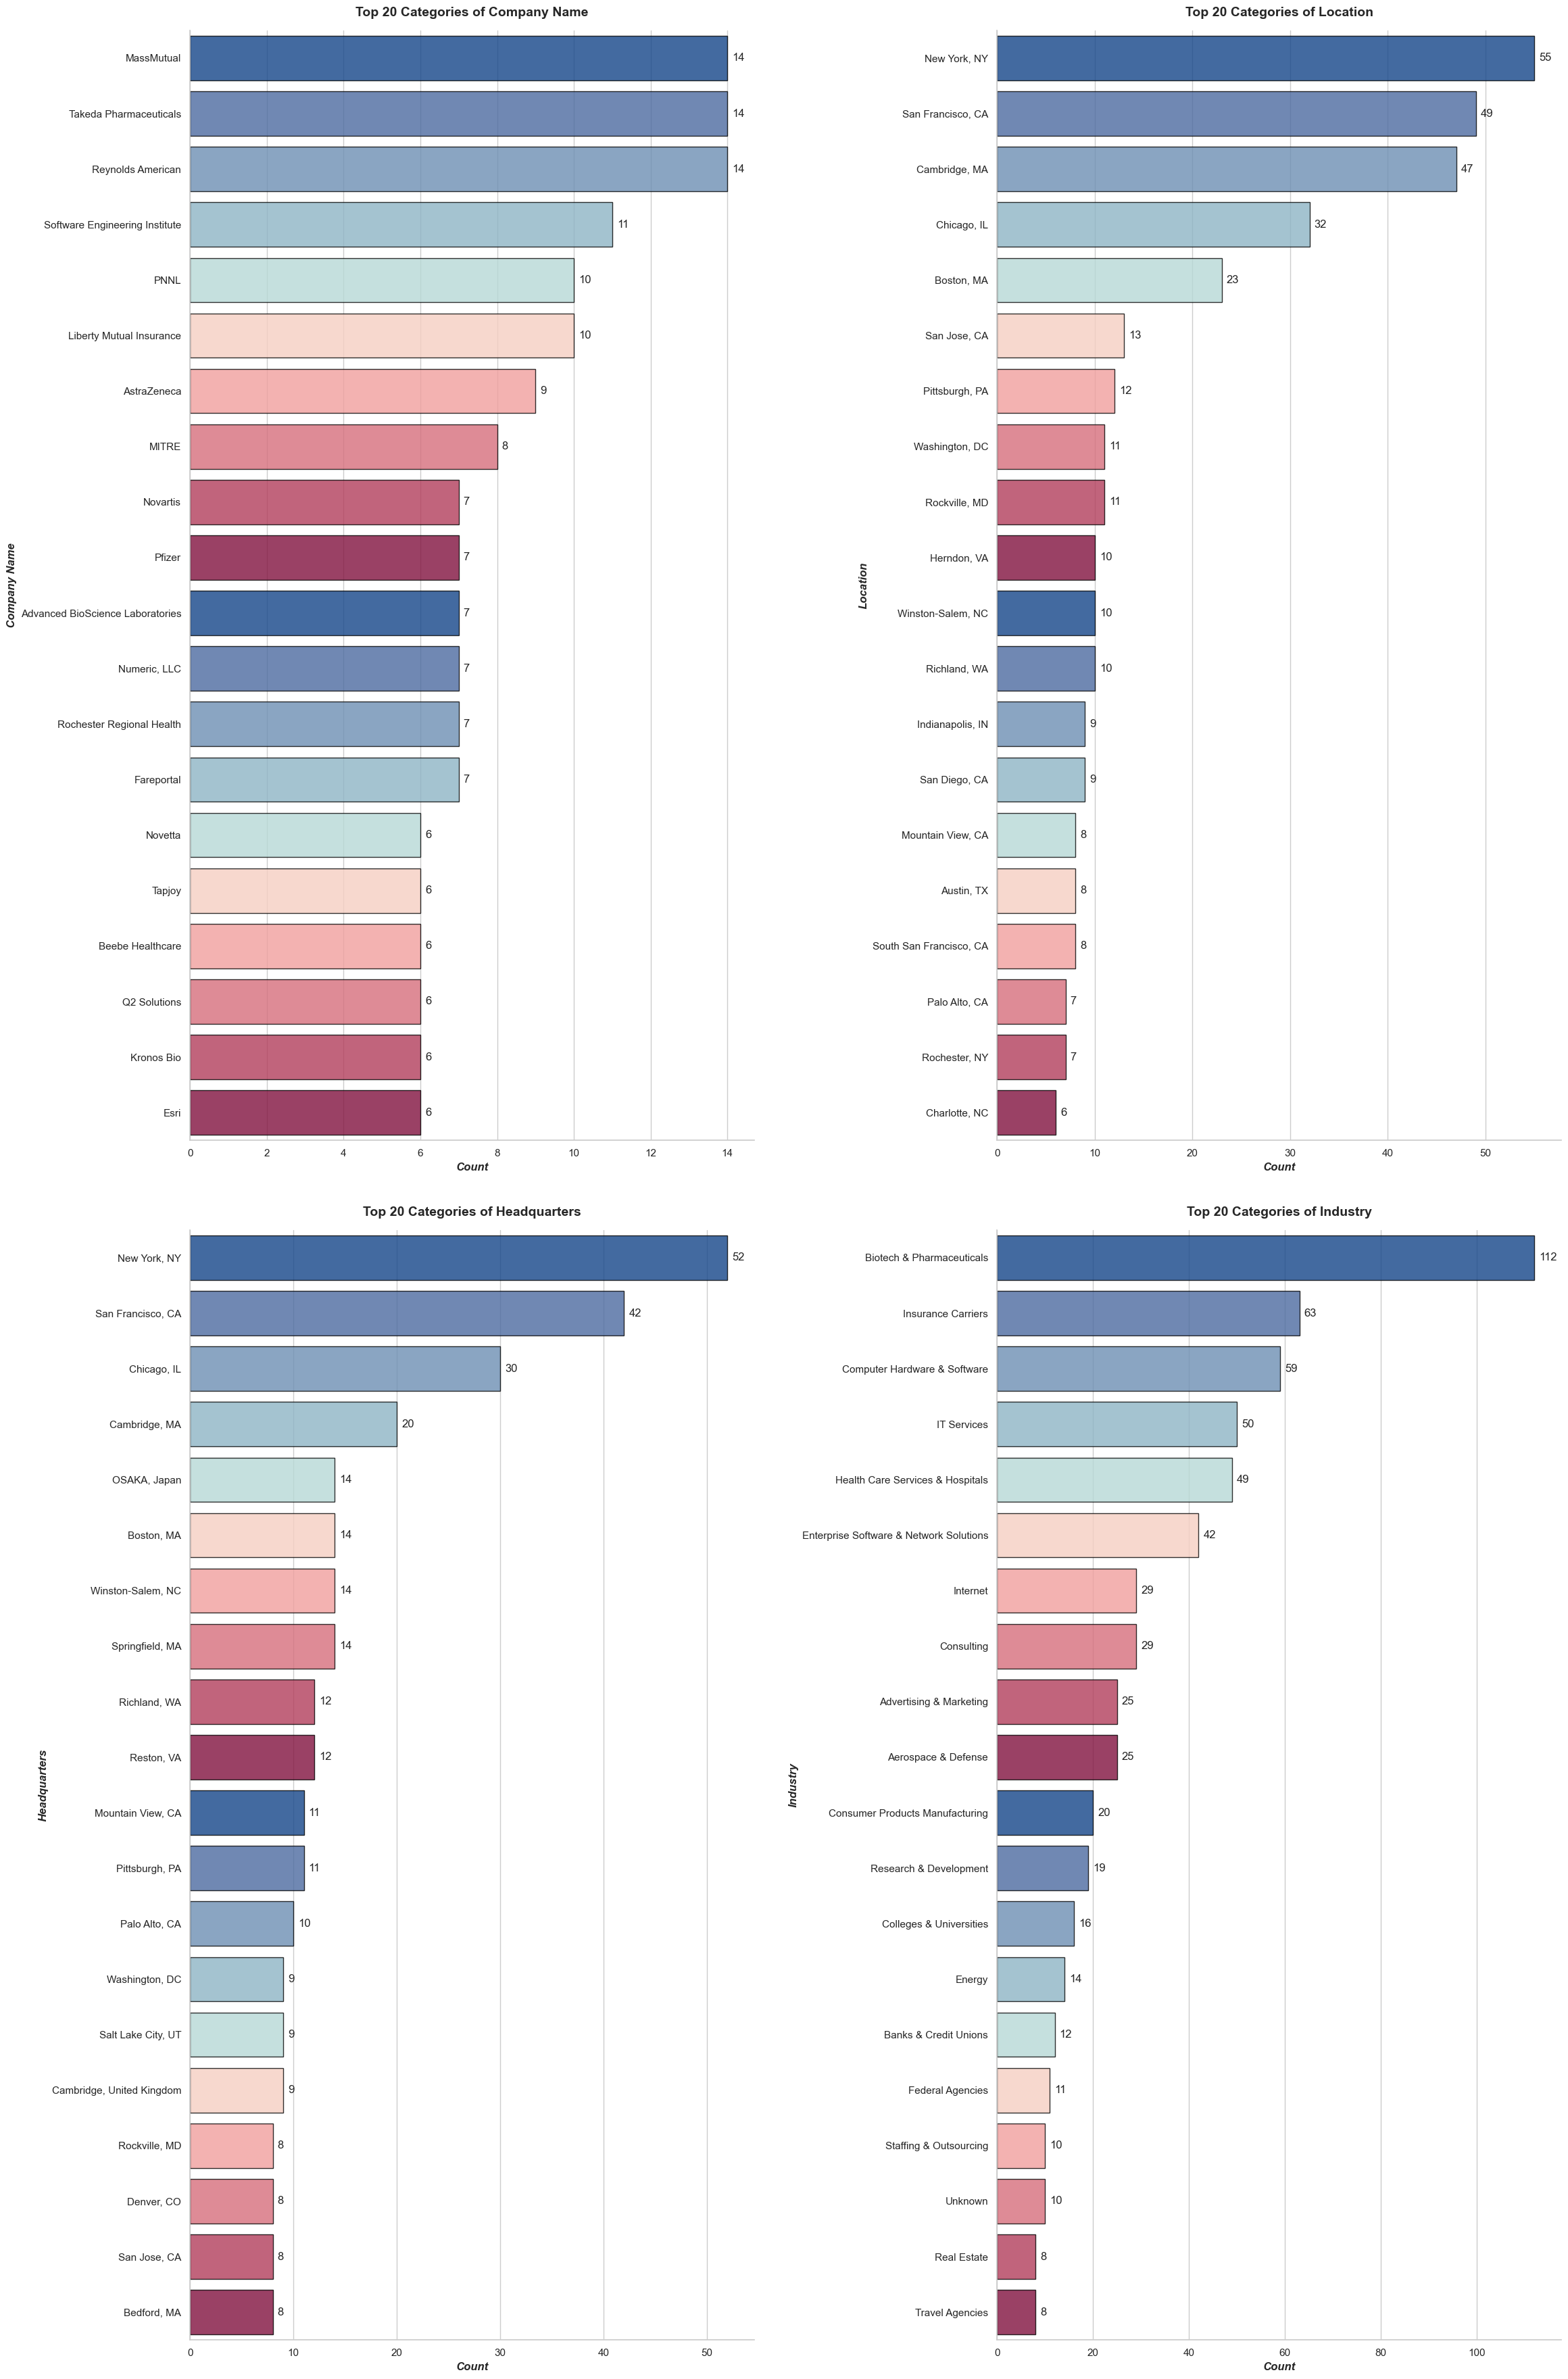

In [11]:
all_object_columns = df.select_dtypes(include=['object']).columns

excluded_object_columns = [col for col in all_object_columns if col not in object_columns]

fig, axes = plt.subplots(2, 2, figsize=(24, 36))

for col, ax in zip(excluded_object_columns, axes.ravel()):
    value_counts = df[col].value_counts().head(20)

    sns.barplot(y=value_counts.index, x=value_counts.values, ax=ax, palette=cmap10, alpha=0.8, edgecolor='black')
    ax.set_title(f'Top 20 Categories of {col}', fontdict=font_tit, pad=15)
    ax.set_xlabel('Count', fontdict=font_ax)
    ax.set_ylabel(col, fontdict=font_ax)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=5)

sns.despine(top=True, right=True)
plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> Job Market Concentration:  
>  
> - **Data-related roles** are highly sought after, with **Data Scientist** being the most dominant.  
>  
> - Jobs are concentrated in **major tech and economic hubs** like **New York, San Francisco, and Cambridge**.  
>  
> - Large companies (1001+ employees) account for most job postings, suggesting stronger hiring capacity in established firms.  
>  
> Industry Trends:  
>  
> - **Biotech & Pharmaceuticals, Insurance, and IT** are leading industries for data roles.  
>  
> - The prevalence of **Biotech & Pharma** suggests a growing demand for data professionals in healthcare and life sciences.  
>  
> - **Enterprise Software & Network Solutions** is also significant, reflecting the importance of cloud computing, AI, and big data.  
>  
> Company Characteristics:  
>  
> - **Private companies** dominate hiring, indicating startups and mid-sized firms are actively expanding.  
>  
> - Many companies have **undisclosed revenue**, but those with **$10B+ revenue** also contribute significantly to hiring.  
>  
> - Most firms are headquartered in **major U.S. cities**, though some international presence (Osaka, Cambridge, UK) is noted.  
>  
> Skills & Seniority:  
>  
> - **SQL, Python, and Excel** are the most in-demand technical skills.  
> - **Senior/Principal roles** make up a significant portion, indicating a demand for experienced professionals.  
> - **Entry-level positions are scarce**, suggesting limited opportunities for beginners or recent graduates.  

> **Summaries**:  
>  
> - The **data job market is dominated by established firms in tech-heavy industries**, with strong hiring in major U.S. cities.  
>  
> - **Biotech, Pharma, and IT are key sectors**, signaling demand for data expertise in healthcare and technology.  
>  
> - **Experienced professionals have more opportunities**, while entry-level roles are relatively limited.  

### **2.2. Analysis (Bivariate Analysis)**

#### ***a. Job-related group***: `job_simplified`, `seniority`, `Industry`, `Sector`

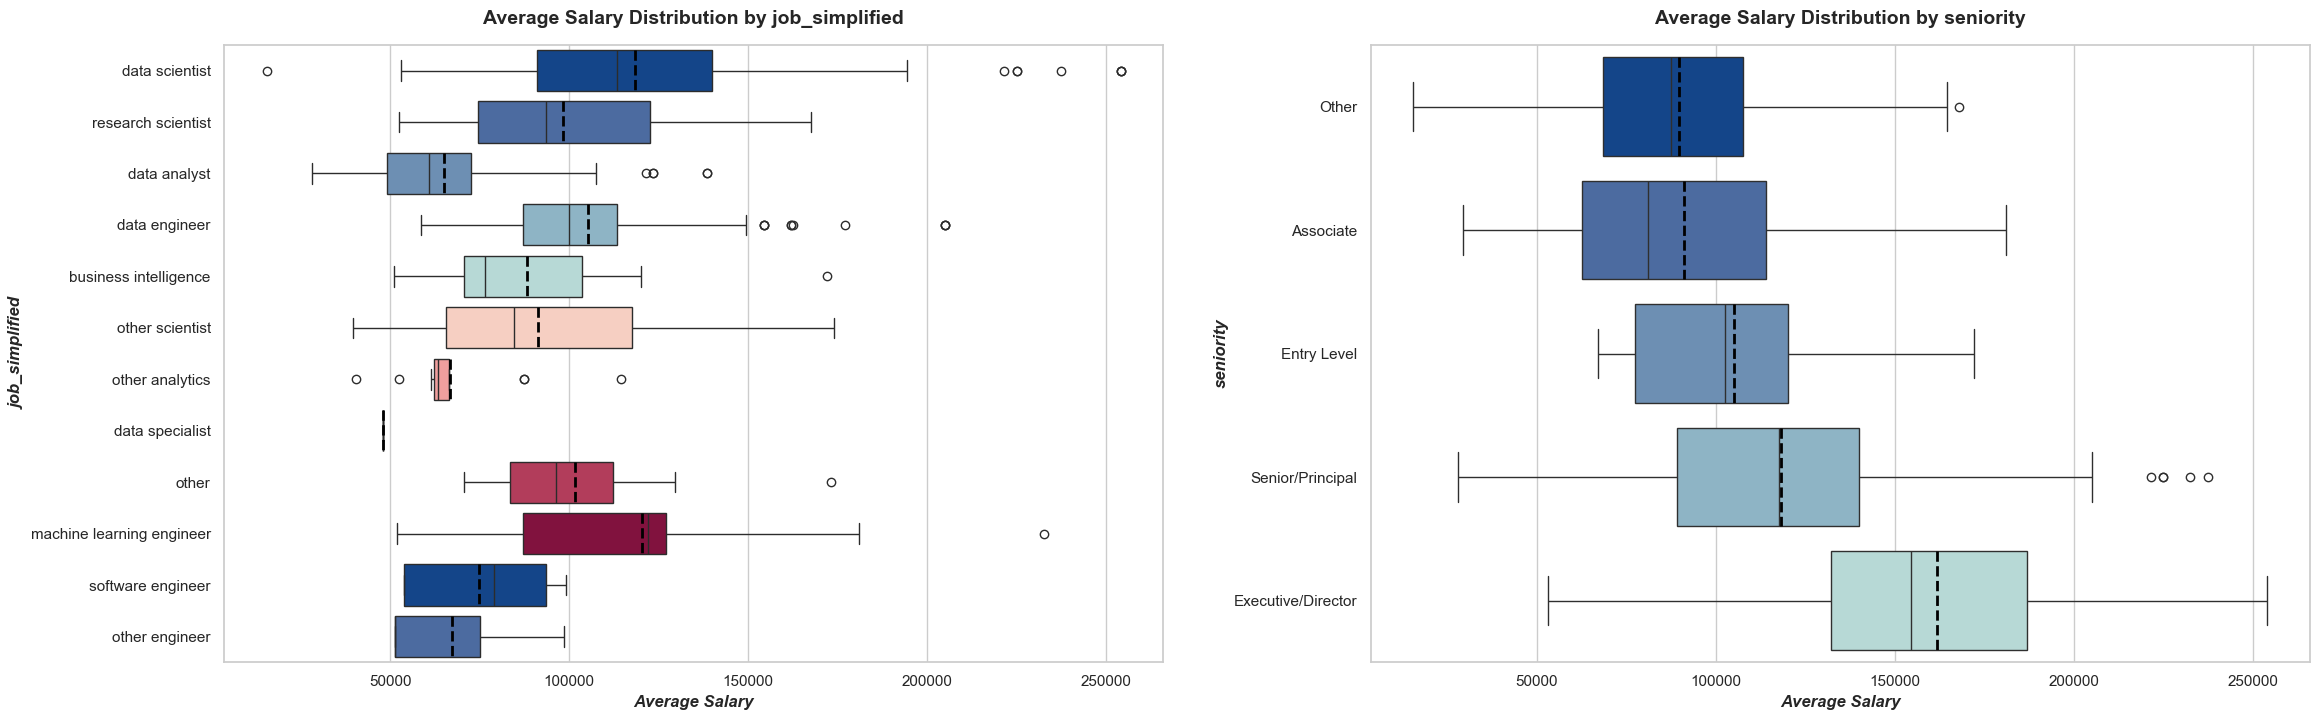

In [12]:
_, axes = plt.subplots(1, 2, figsize=(24, 8))

for col, ax in zip(['job_simplified', 'seniority'], axes):
    sns.boxplot(data=df, x='Average Salary', y=col, ax=ax, palette=cmap10,
                showmeans=True, meanline=True,
                meanprops={'color': 'black', 'linestyle': '--', 'linewidth': 2})

    mean_salary = df.groupby(col)['Average Salary'].mean().sort_values()

    ax.set_title(f'Average Salary Distribution by {col}', fontdict=font_tit, pad=15)
    ax.set_xlabel("Average Salary", fontdict=font_ax)
    ax.set_ylabel(col, fontdict=font_ax)

plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> Salary Distribution by Job Title:  
> - Roles directly related to Data Science and AI, such as **Data Scientist** and **Machine Learning Engineer**, command the highest salaries, reflecting their high market demand and value.  
> - Positions focused on data analysis or specialized tasks, such as **Data Analyst** and **Business Intelligence** roles, tend to have lower salary ranges.  
>  
> Salary Distribution by Seniority Level:  
> - **Highest**: Executive/Director – Average salary ranges from $130,000 to $185,000, with some outliers exceeding $250,000.  
> - **Mid-range**: Senior/Principal – Salaries typically fall between $90,000 and $140,000, with a few outliers above $200,000.  
> - **Lowest**: Other roles – Salaries range from $70,000 to $110,000, with fewer extreme values.  

> **Summaries**:  
> - Higher-level positions (both in job role and seniority) consistently offer **substantially higher salaries** than lower-level ones.  
> - Lower-level roles not only have lower average salaries but also exhibit **narrower salary distributions**, indicating less variation in pay.

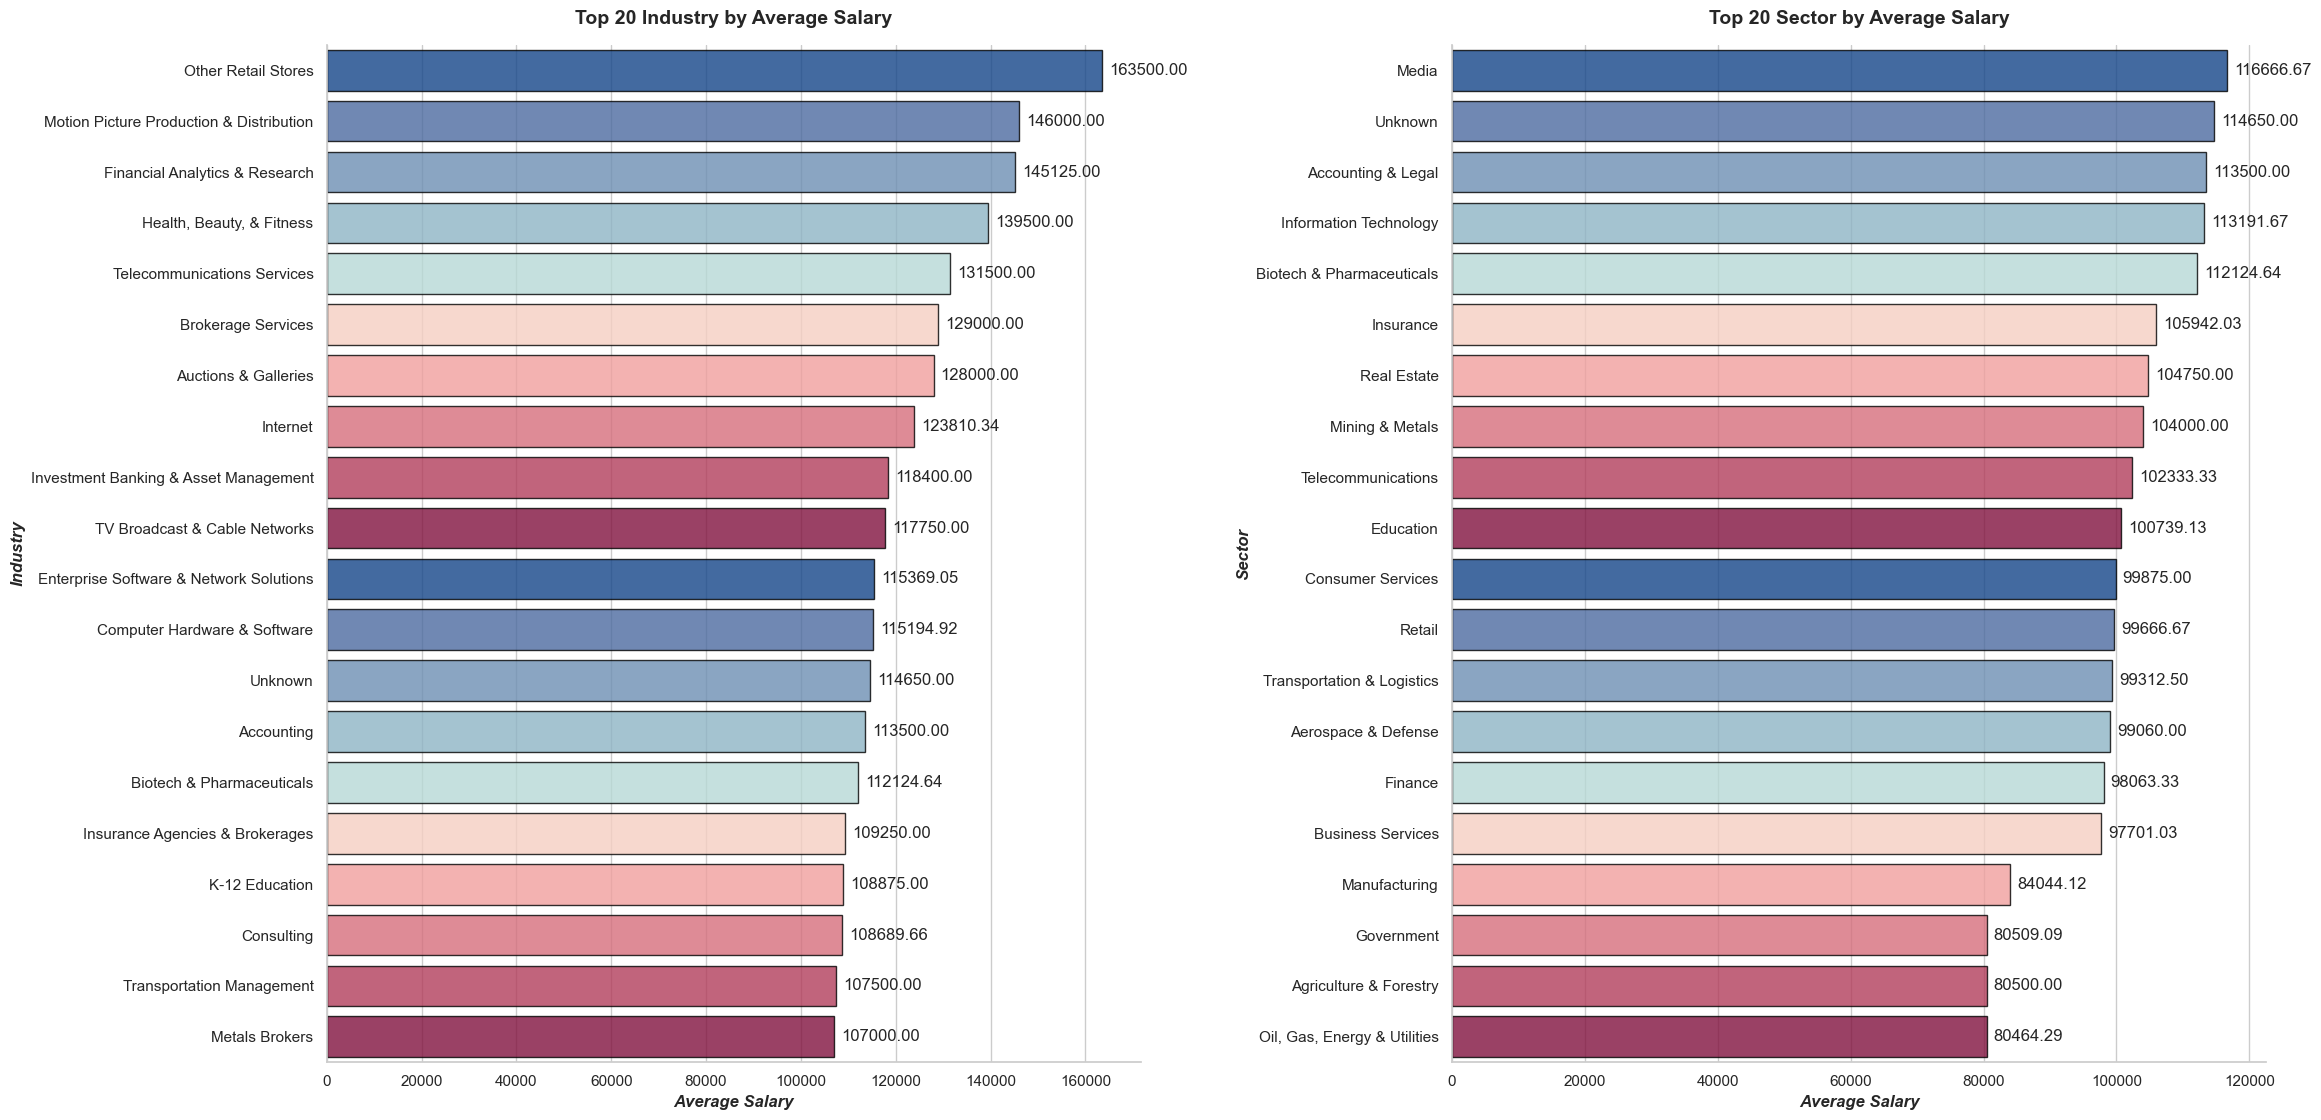

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

for col, ax in zip(['Industry', 'Sector'], axes):
    avg_salary_by_category = df.groupby(col)["Average Salary"].mean().sort_values(ascending=False)
    top_n                  = avg_salary_by_category.head(20)

    sns.barplot(x=top_n.values, y=top_n.index, palette=cmap10, ax=ax, alpha=0.8, edgecolor='black')

    ax.set_title(f'Top 20 {col} by Average Salary', fontdict=font_tit, pad=15)
    ax.set_xlabel("Average Salary", fontdict=font_ax)
    ax.set_ylabel(col, fontdict=font_ax)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5)

sns.despine(top=True, right=True)
plt.tight_layout(pad=3)
plt.show()

> **Observations & Summary**:  
>  
> - Industries associated with finance, technology, and entertainment, such as Motion Picture Production, Financial Analytics, and Telecommunications, offer the highest salaries.  
>  
> - Some industries, including K-12 Education and Metals Brokers, remain in the Top 20 but have relatively lower average salaries compared to the top-tier industries.  
>  
> - Media, Information Technology, and Biotech & Pharmaceuticals rank as the highest-paying sectors.  
>  
> - Government, Agriculture & Forestry, and Oil, Gas, Energy & Utilities have lower average salaries but still remain within the Top 20.  

#### ***b. Company-related group***: `Company Name`, `Size`, `Age`, `Type of ownership`, `Rating`, `Rating Category`, `Revenue`

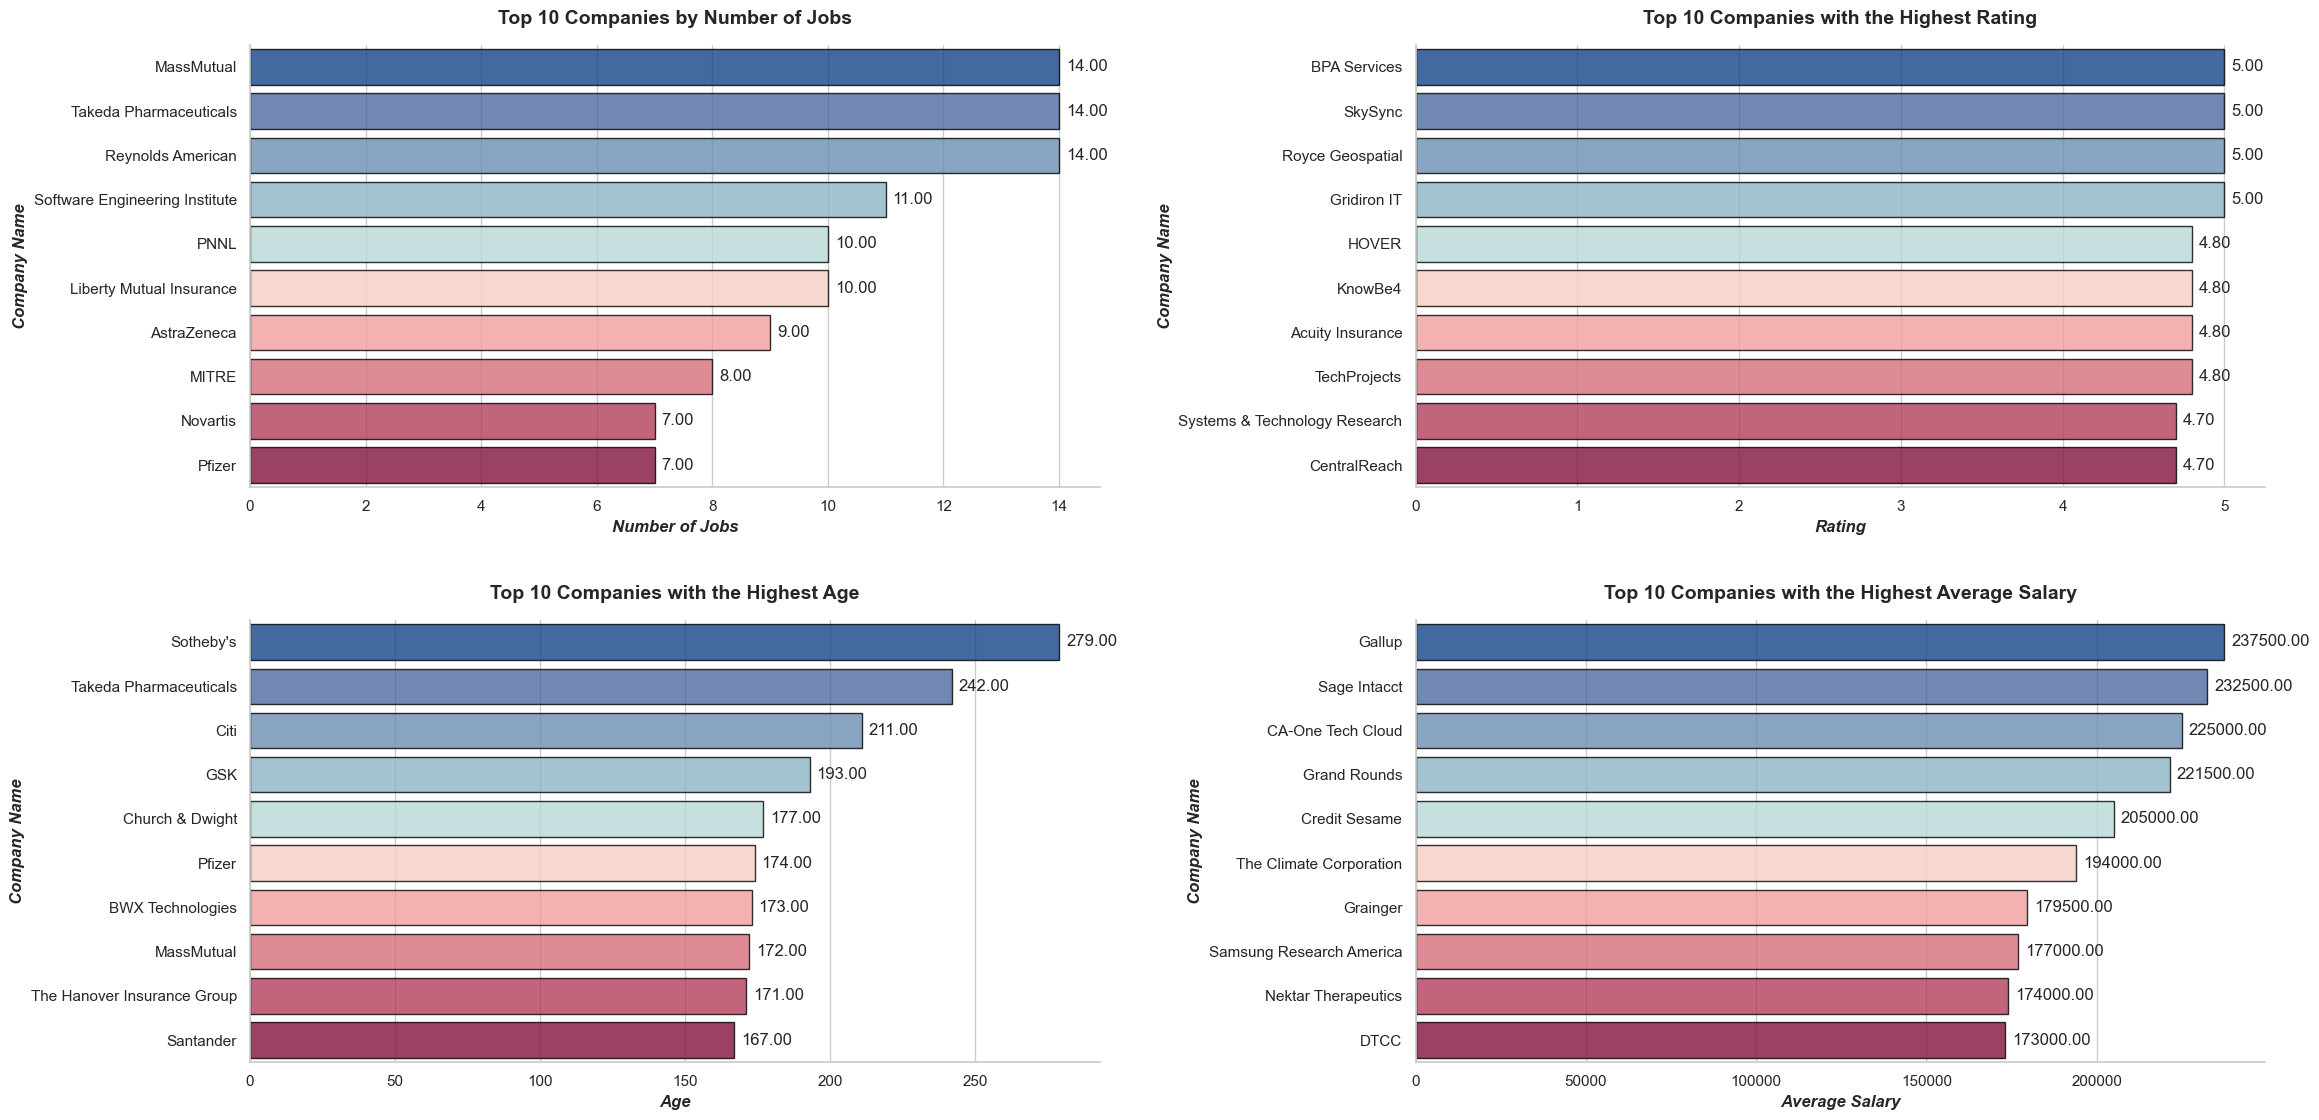

In [14]:
_, axes = plt.subplots(2, 2, figsize=(24, 12))

for col, ax in zip(['Company Name', 'Rating', 'Age', 'Average Salary'], axes.ravel()):
    if col == 'Company Name':
        top_companies = df['Company Name'].value_counts().head(10)
        sns.barplot(x=top_companies.values, y=top_companies.index, palette=cmap10, ax=ax, alpha=0.8, edgecolor='black')

        ax.set_title("Top 10 Companies by Number of Jobs", fontdict=font_tit, pad=15)
        ax.set_xlabel("Number of Jobs", fontdict=font_ax)
        ax.set_ylabel("Company Name", fontdict=font_ax)
    else:
        top_by_category = df[['Company Name', col]].groupby('Company Name').mean().sort_values(col, ascending=False)
        top_n           = top_by_category.head(10)

        sns.barplot(x=top_n[col], y=top_n.index, palette=cmap10, ax=ax, alpha=0.8, edgecolor='black')

        ax.set_title(f"Top 10 Companies with the Highest {col}", fontdict=font_tit, pad=15)
        ax.set_xlabel(col, fontdict=font_ax)
        ax.set_ylabel("Company Name", fontdict=font_ax)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5)

sns.despine(top=True, right=True)
plt.tight_layout(pad=3)
plt.show()

> **Observations & Summary**:  
>  
> - Insurance, pharmaceutical, and tech firms dominate in job availability.  
>  
> - Tech, insurance, and data analytics firms receive top ratings.  
>  
> - Finance, insurance, and pharmaceutical firms tend to have long histories.  
>  
> - High salaries are concentrated in tech and research-focused firms.  

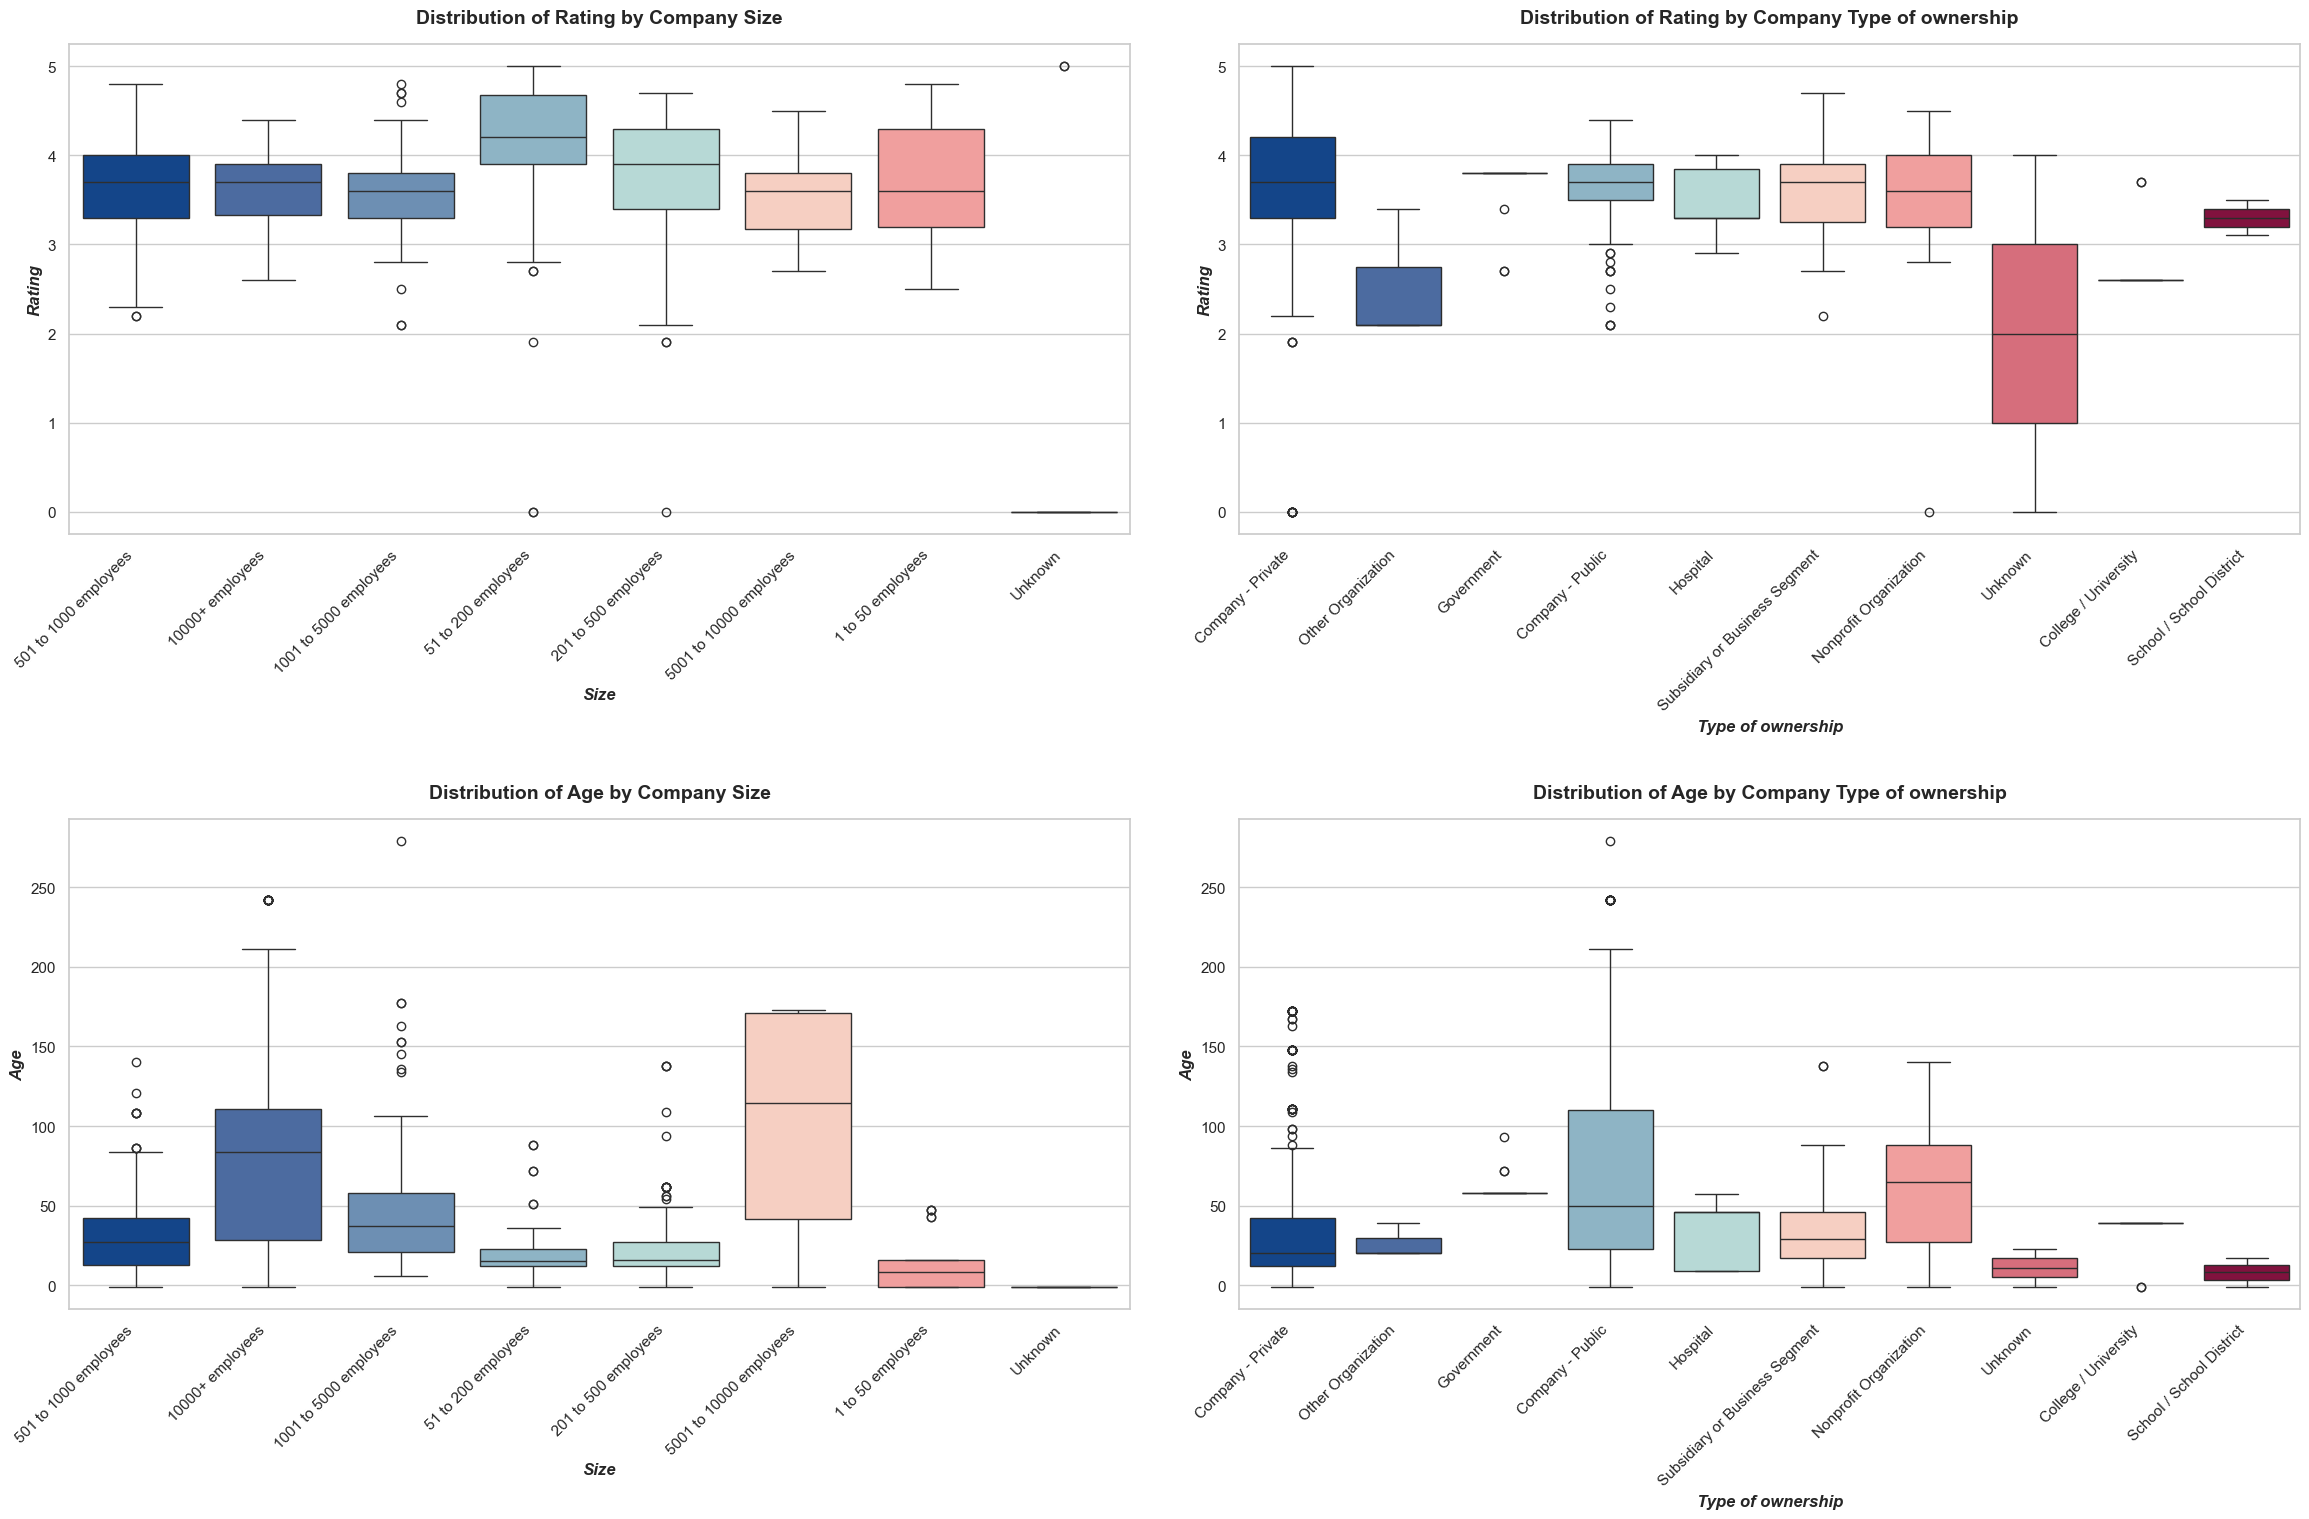

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

ycols = ['Rating', 'Age']
xcols = ['Size', 'Type of ownership']

for i, (ycol, ax_row) in enumerate(zip(ycols, axes)):
    for j, (xcol, ax) in enumerate(zip(xcols, ax_row)):
        sns.boxplot(data=df, x=xcol, y=ycol, ax=ax, palette=cmap10)

        ax.set_title(f'Distribution of {ycol} by Company {xcol}', fontdict=font_tit, pad=15)
        ax.set_xlabel(xcol, fontdict=font_ax)
        ax.set_ylabel(ycol, fontdict=font_ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> - Rating by Company Size: Larger companies tend to have higher and more stable ratings, while smaller and unknown firms show greater variability.  
>  
> - Rating by Company Ownership: Private companies receive the highest ratings, while government and unknown entities have lower scores.  
>  
> - Age by Company Size: Smaller companies tend to be older, while larger firms are generally younger.  
>  
> - Age by Company Ownership: Public companies and government organizations have the longest histories, while private firms are relatively younger.  

> **Summaries**:  
>  
> - Ratings: Larger and private companies receive higher, more stable ratings.  
>  
> - Age: Smaller firms and public entities tend to be older.  

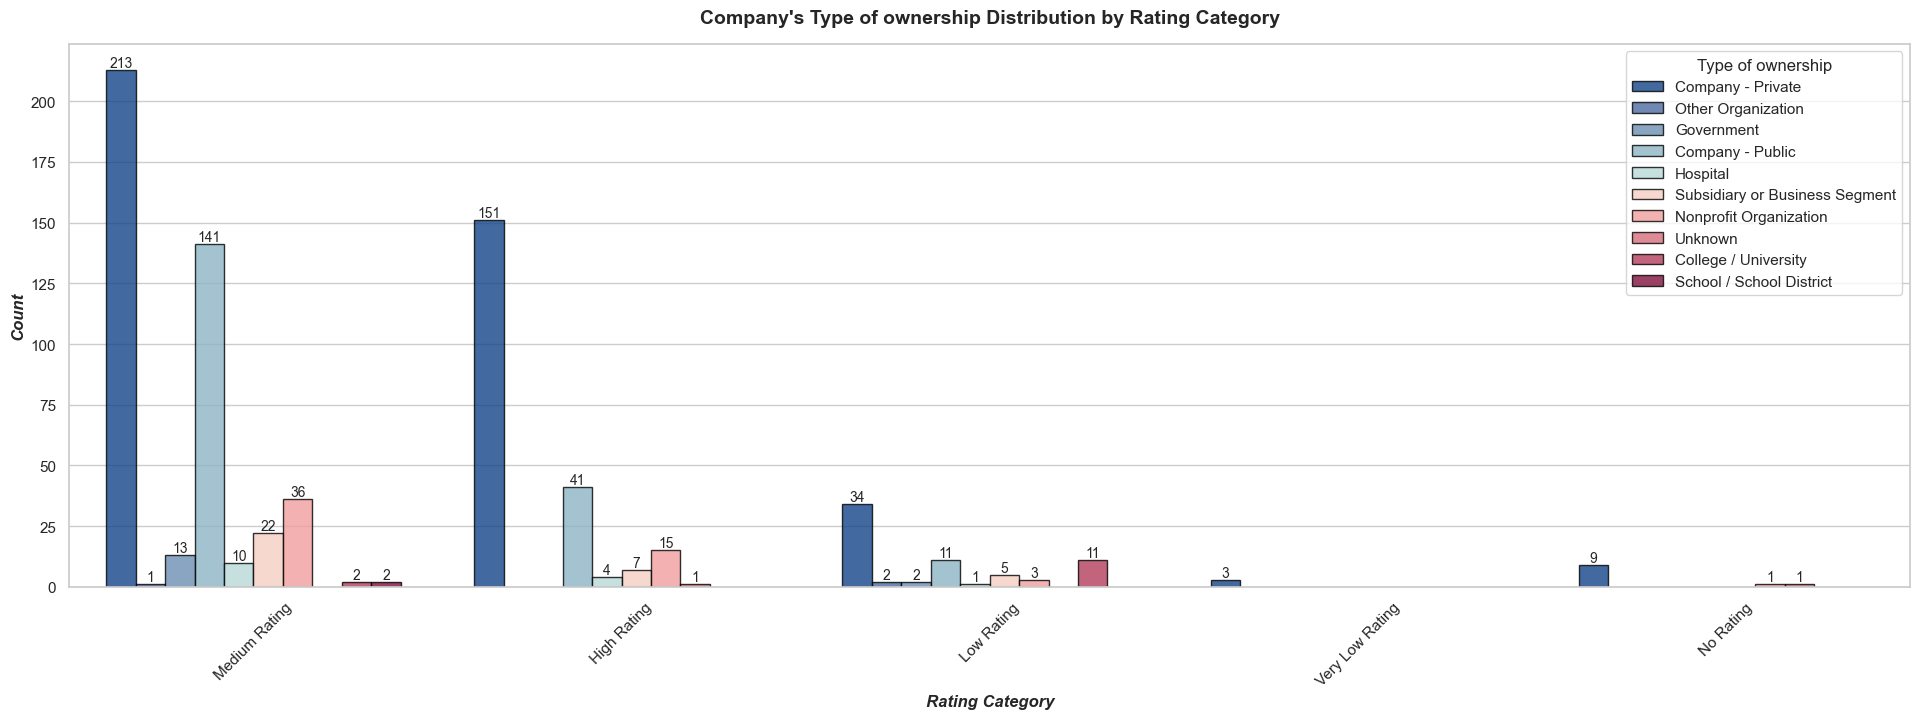

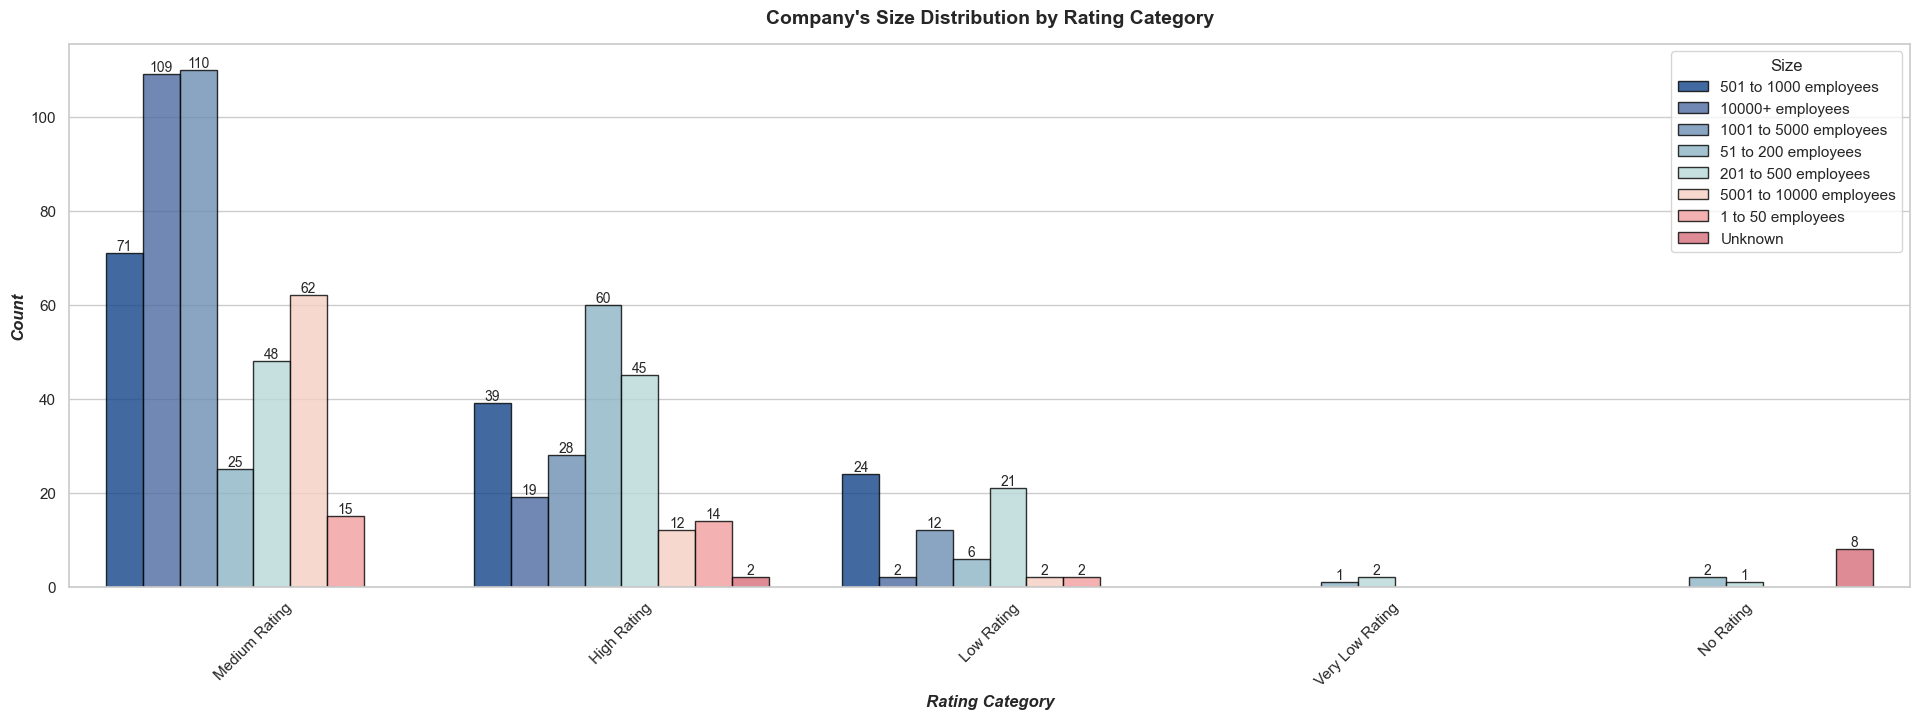

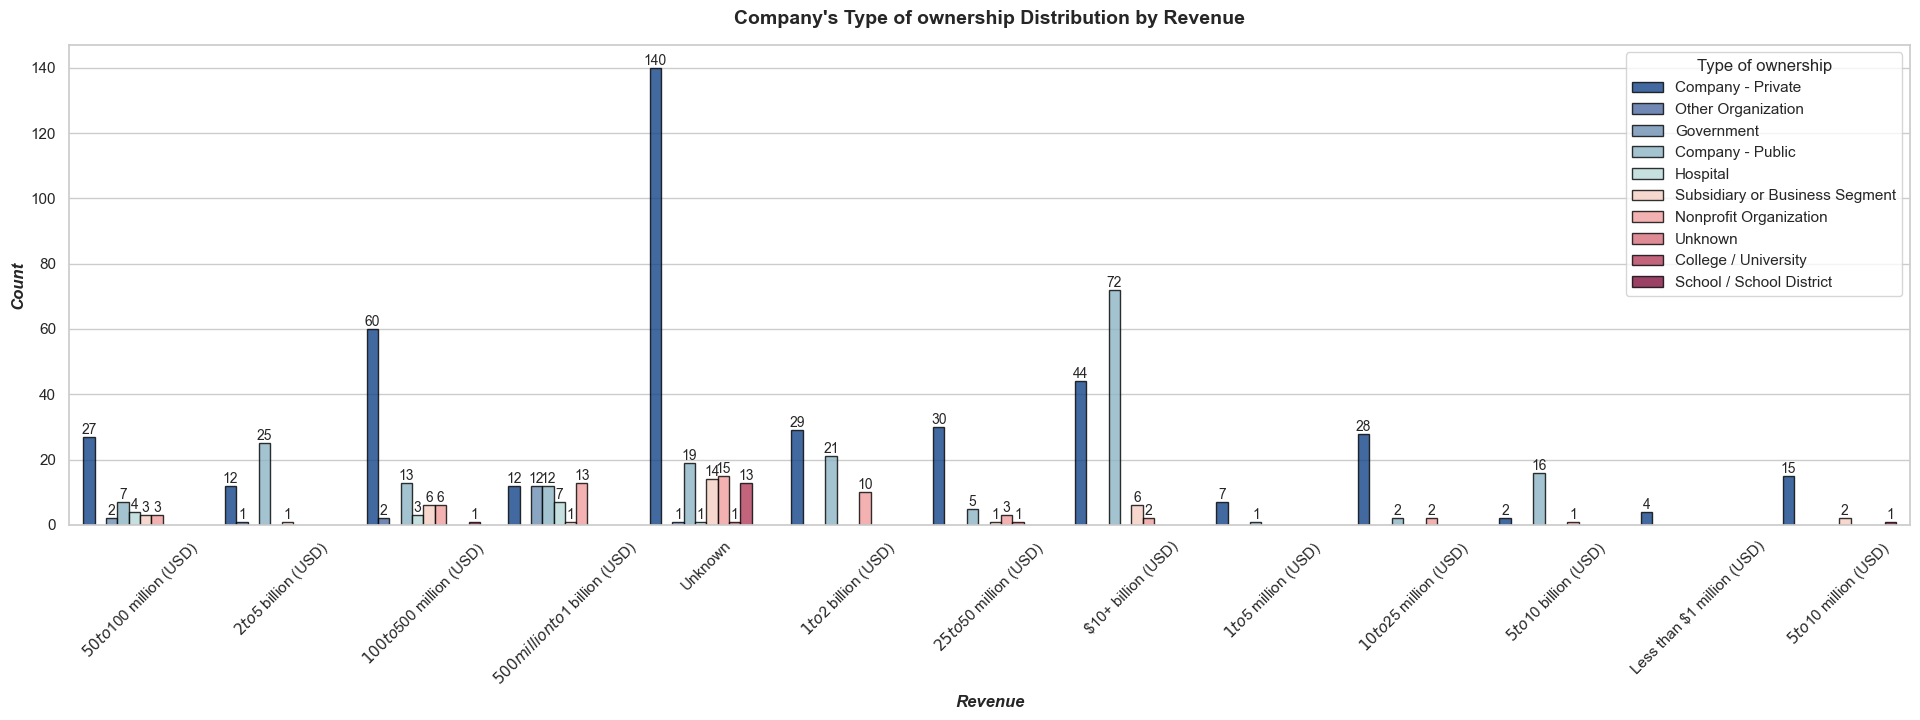

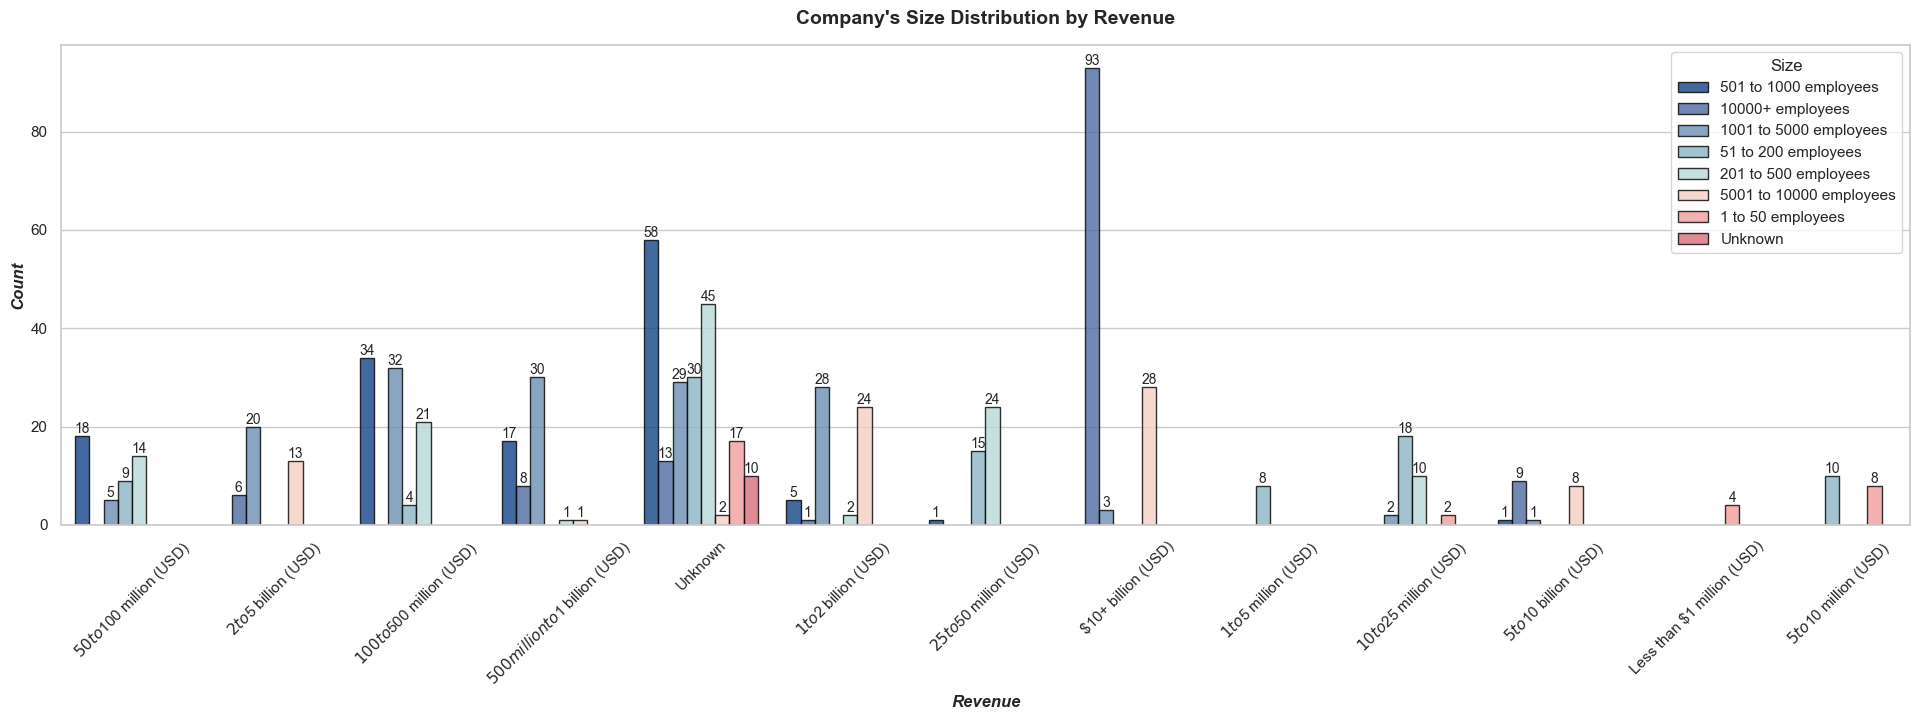

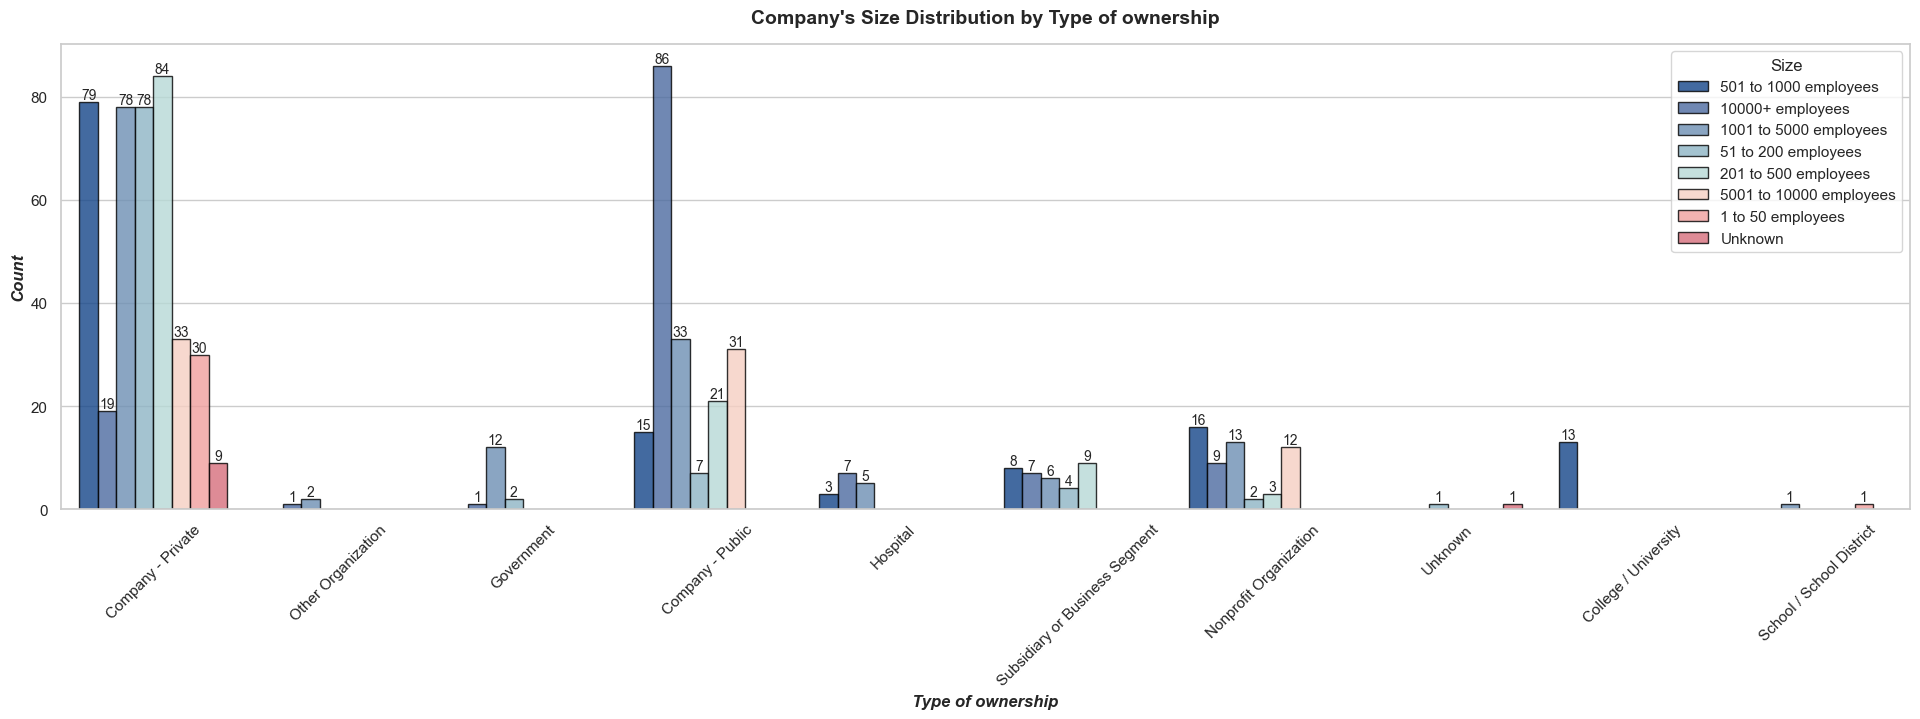

In [16]:
pairs = list(itertools.product(
    ['Rating Category', 'Revenue', 'Type of ownership'],
    ['Type of ownership', 'Size']
))

for pair in pairs:
    if pair[0] != pair[1]:
        plt.figure(figsize=(20, 8))
        sns.countplot(x=pair[0], hue=pair[1], data=df, palette=cmap10, alpha=0.8, edgecolor='black')

        plt.title(f"Company's {pair[1]} Distribution by {pair[0]}", fontdict=font_tit, pad=15)
        plt.xlabel(pair[0], fontdict=font_ax)
        plt.ylabel("Count", fontdict=font_ax)
        plt.xticks(rotation=45)

        for container in plt.gca().containers:
            plt.gca().bar_label(container, fmt='%d', label_type='edge', fontsize=10)

        plt.tight_layout(pad=3)
        plt.show()

> **Observations**:  
>  
> - Ownership Distribution by Rating Category: Private and public companies dominate high and medium ratings, while nonprofits and universities mostly appear in the medium category.  
>  
> - Company Size Distribution by Rating Category: Larger companies (500+ employees) tend to receive higher ratings, while smaller firms are less represented in high-rating groups.  
>  
> - Ownership Distribution by Revenue: Private companies dominate all revenue groups, while public companies are more concentrated in high-revenue categories.  
>  
> - Company Size Distribution by Revenue: Larger companies (1000+ employees) are prevalent in high-revenue groups, while smaller firms are mostly in low-revenue categories.  
>  
> - Company Size Distribution by Ownership Type: Private and public companies are dominant across all sizes, with public firms more concentrated in the largest category (10,000+ employees).  

> **Summaries**:  
>  
> - **Private and public companies** lead in high ratings and high revenue, especially at large scales.  
>  
> - **Nonprofits and universities** are mostly in mid-level ratings, revenue, and company sizes.  
>  
> - **Larger firms** are more associated with high ratings and revenue, while smaller firms are less frequently rated or have lower revenue.  


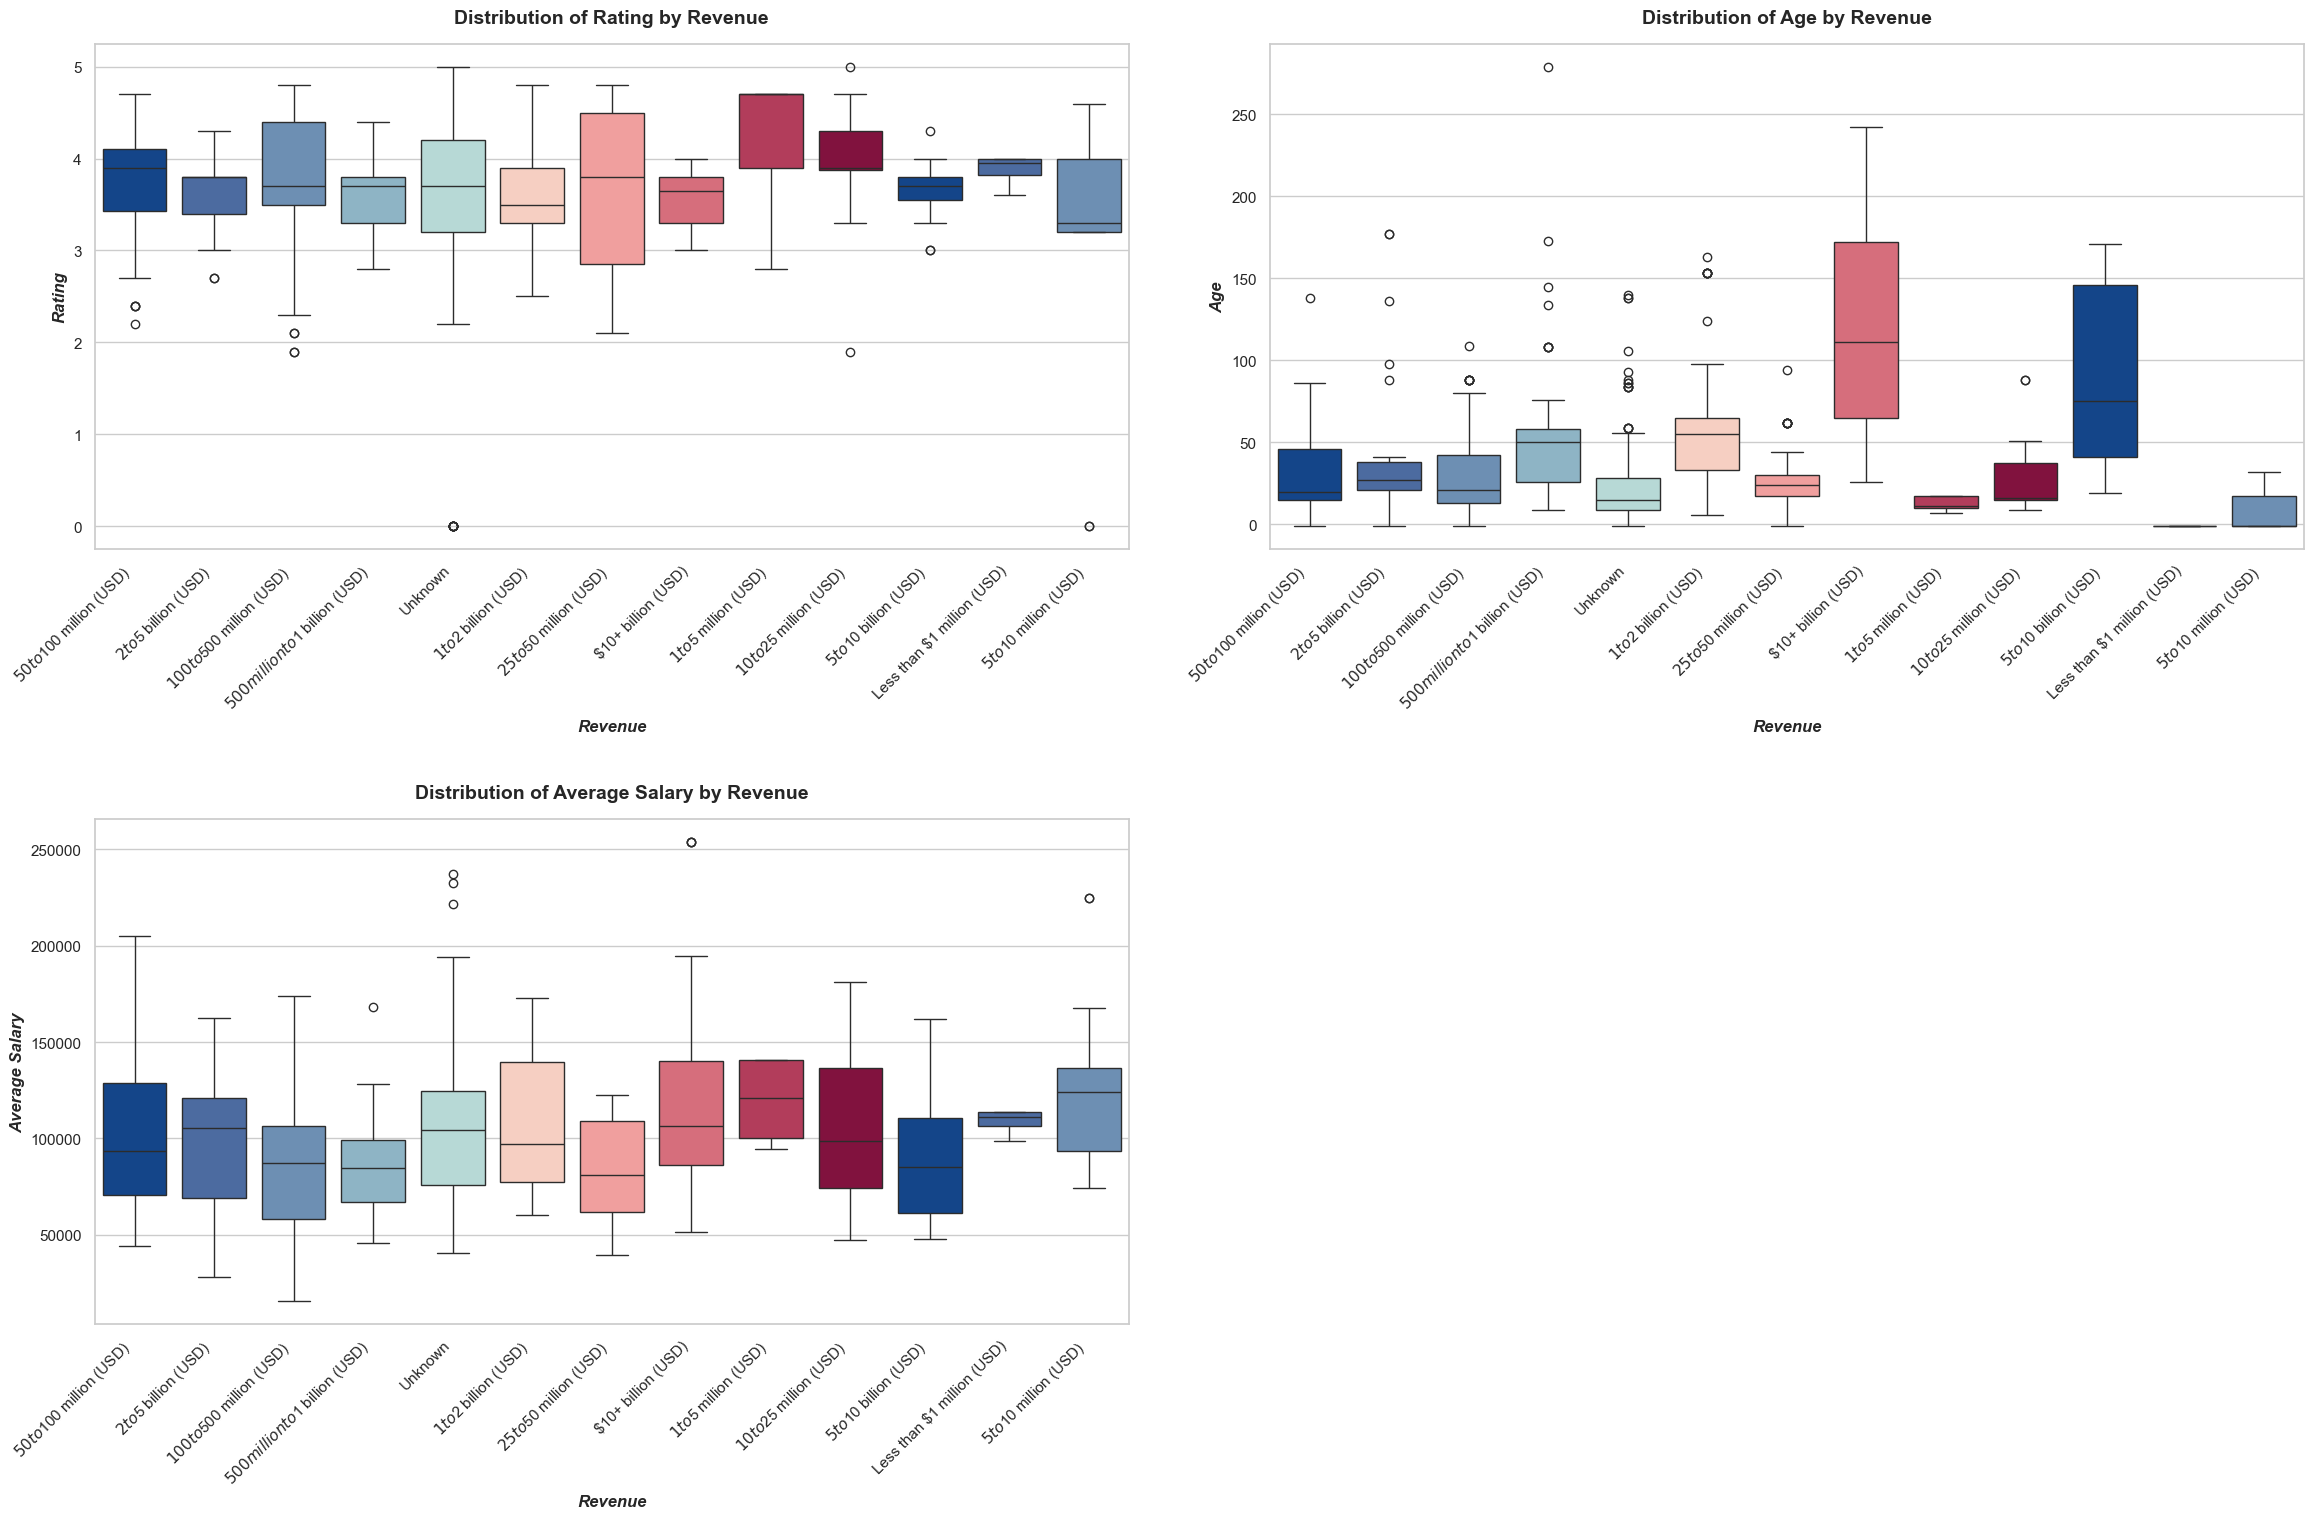

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

for col, ax in zip(['Rating', 'Age', 'Average Salary'], axes.ravel()):
    sns.boxplot(data=df, x='Revenue', y=col, ax=ax, palette=cmap10)

    ax.set_title(f'Distribution of {col} by Revenue', fontdict=font_tit, pad=15)
    ax.set_xlabel("Revenue", fontdict=font_ax)
    ax.set_ylabel(col, fontdict=font_ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

for ax in axes.ravel()[len(['Rating', 'Age', 'Average Salary']):]:
    ax.axis('off')

plt.tight_layout(pad=3)
plt.show()

> **Observations & Summaries**:  
>  
> - **Rating**: Higher revenue correlates with higher and more stable ratings, while small or unknown-revenue companies tend to have lower ratings.  
>  
> - **Company Age**: Larger revenue companies are generally older, while smaller firms tend to be younger.  
>  
> - **Salary**: High-revenue companies offer higher and more stable salaries, whereas smaller firms have lower and more variable pay.  

#### ***c. Skill-related group***: `Python_yn`, `Spark`, `AWS_yn`, `Excel_yn`, `Tableau_yn`, `SQL_yn`

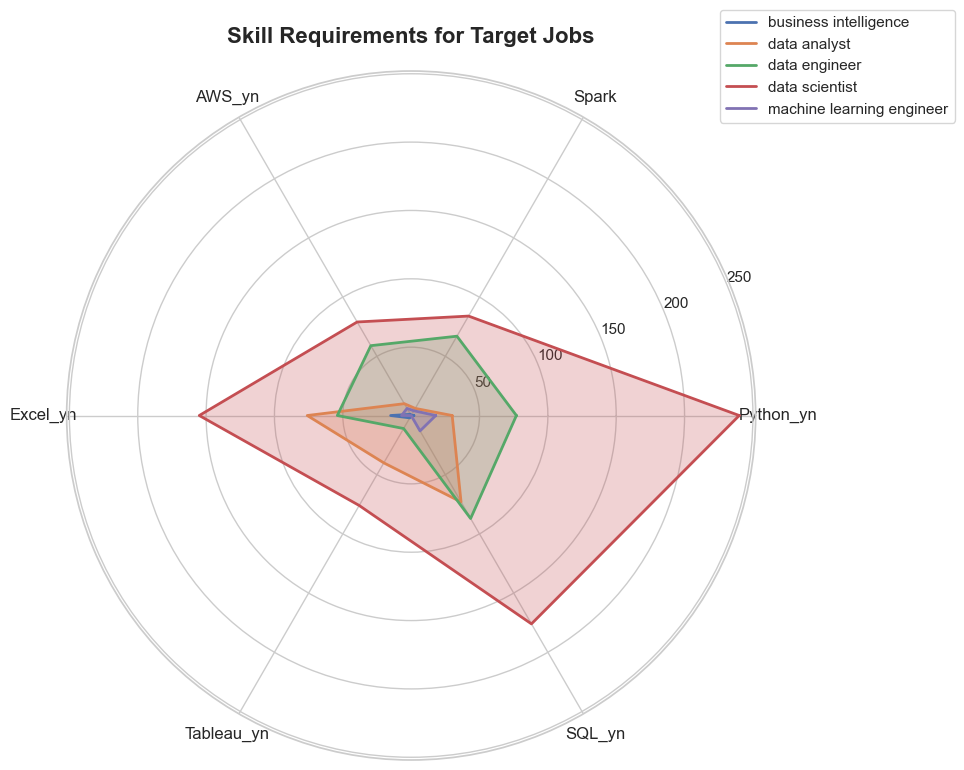

In [18]:
target_jobs     = ['data scientist', 'data analyst', 'data engineer', 'machine learning engineer', 'business intelligence']
required_skills = ['Python_yn', 'Spark', 'AWS_yn', 'Excel_yn', 'Tableau_yn', 'SQL_yn']

filtered_df = df[df['job_simplified'].isin(target_jobs)]
skill_counts = (
    filtered_df.groupby('job_simplified')[required_skills].sum()
)

categories = required_skills
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for job in skill_counts.index:
    values = skill_counts.loc[job].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=job)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

plt.title("Skill Requirements for Target Jobs", size=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

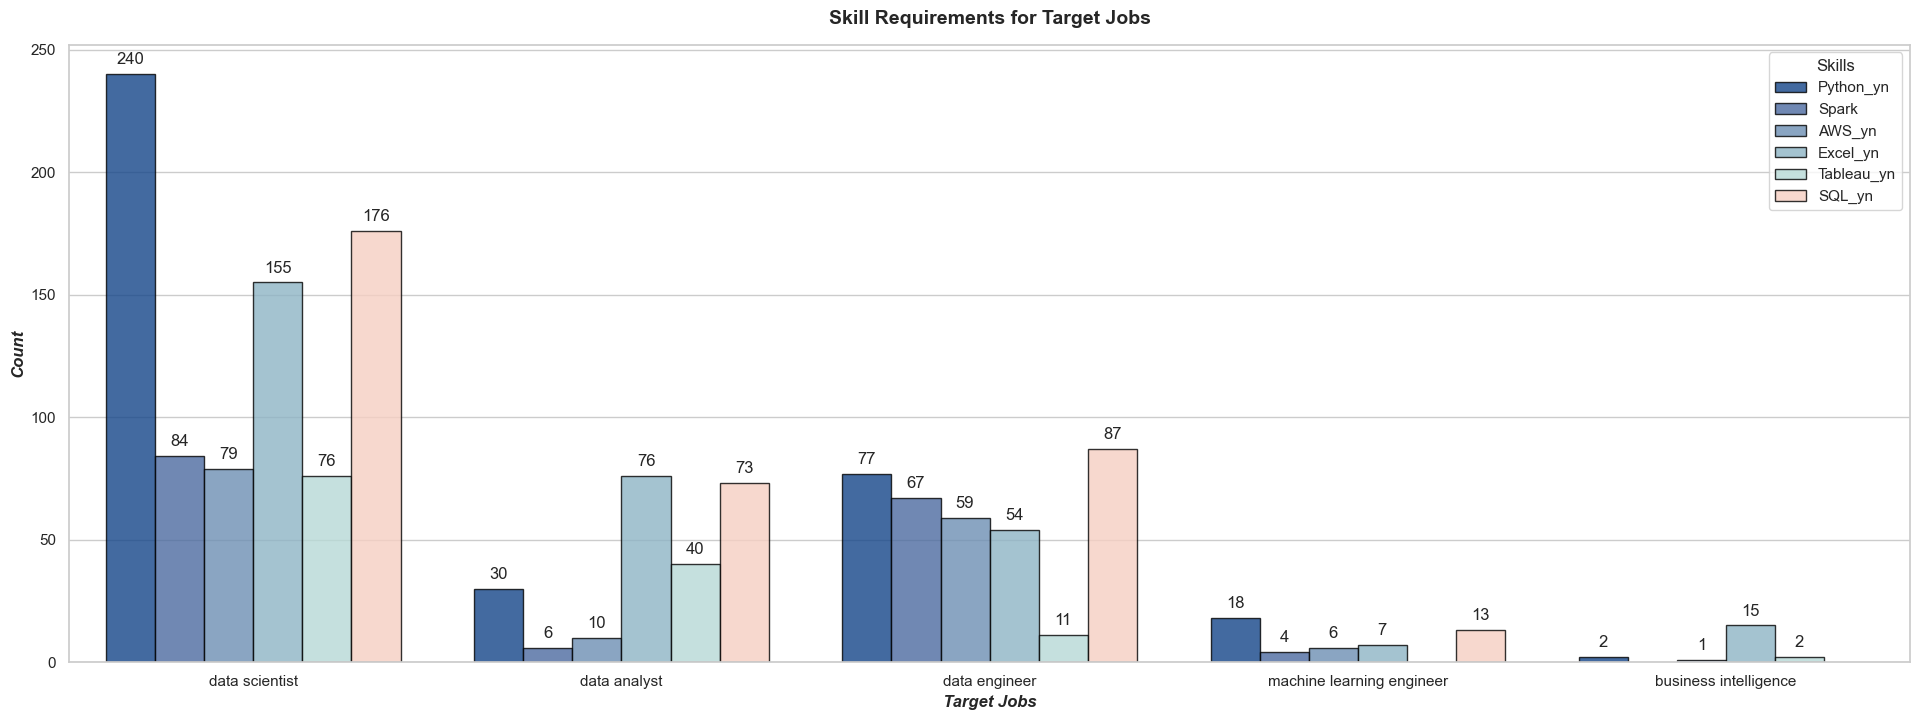

In [19]:
target_jobs     = ['data scientist', 'data analyst', 'data engineer', 'machine learning engineer', 'business intelligence']
required_skills = ['Python_yn', 'Spark', 'AWS_yn', 'Excel_yn', 'Tableau_yn', 'SQL_yn']

filtered_df = df[df['job_simplified'].isin(target_jobs)]
melted_df   = filtered_df.melt(id_vars='job_simplified', value_vars=required_skills, var_name='Skill', value_name='Required')
melted_df   = melted_df[melted_df['Required'] == 1]

plt.figure(figsize=(20, 8))
fg = sns.countplot(data=melted_df, x='job_simplified', hue='Skill', palette=cmap10, alpha=0.8, edgecolor='black')

plt.title("Skill Requirements for Target Jobs", fontdict=font_tit, pad=15)
plt.xlabel("Target Jobs", fontdict=font_ax)
plt.ylabel("Count", fontdict=font_ax)

for container in fg.containers:
    fg.bar_label(container, fmt='%d', label_type='edge', padding=5)

plt.legend(title="Skills")
plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> - Data Scientist: Python, Excel, and SQL are the most critical skills, with AWS, Spark, and Tableau also valued but less frequently required.  
>  
> - Data Analyst: Excel and SQL are the top skills, followed by Python and Tableau; AWS and Spark are less common.  
>  
> - Data Engineer: SQL is the most essential skill, followed by Python, Spark, and AWS, while Tableau is rarely required.  
>  
> - Machine Learning Engineer: Python is the primary skill, with SQL, AWS, and Spark also valued but to a lesser extent.  
>  
> - Business Intelligence: Excel is the most essential skill for this role.  

> **Summary**: Python and SQL are the most in-demand skills, particularly for Data Scientist and Data Engineer roles.  

#### ***d. Location-related group***: `job_state`, `Headquarters`, `Location`, `same_state`

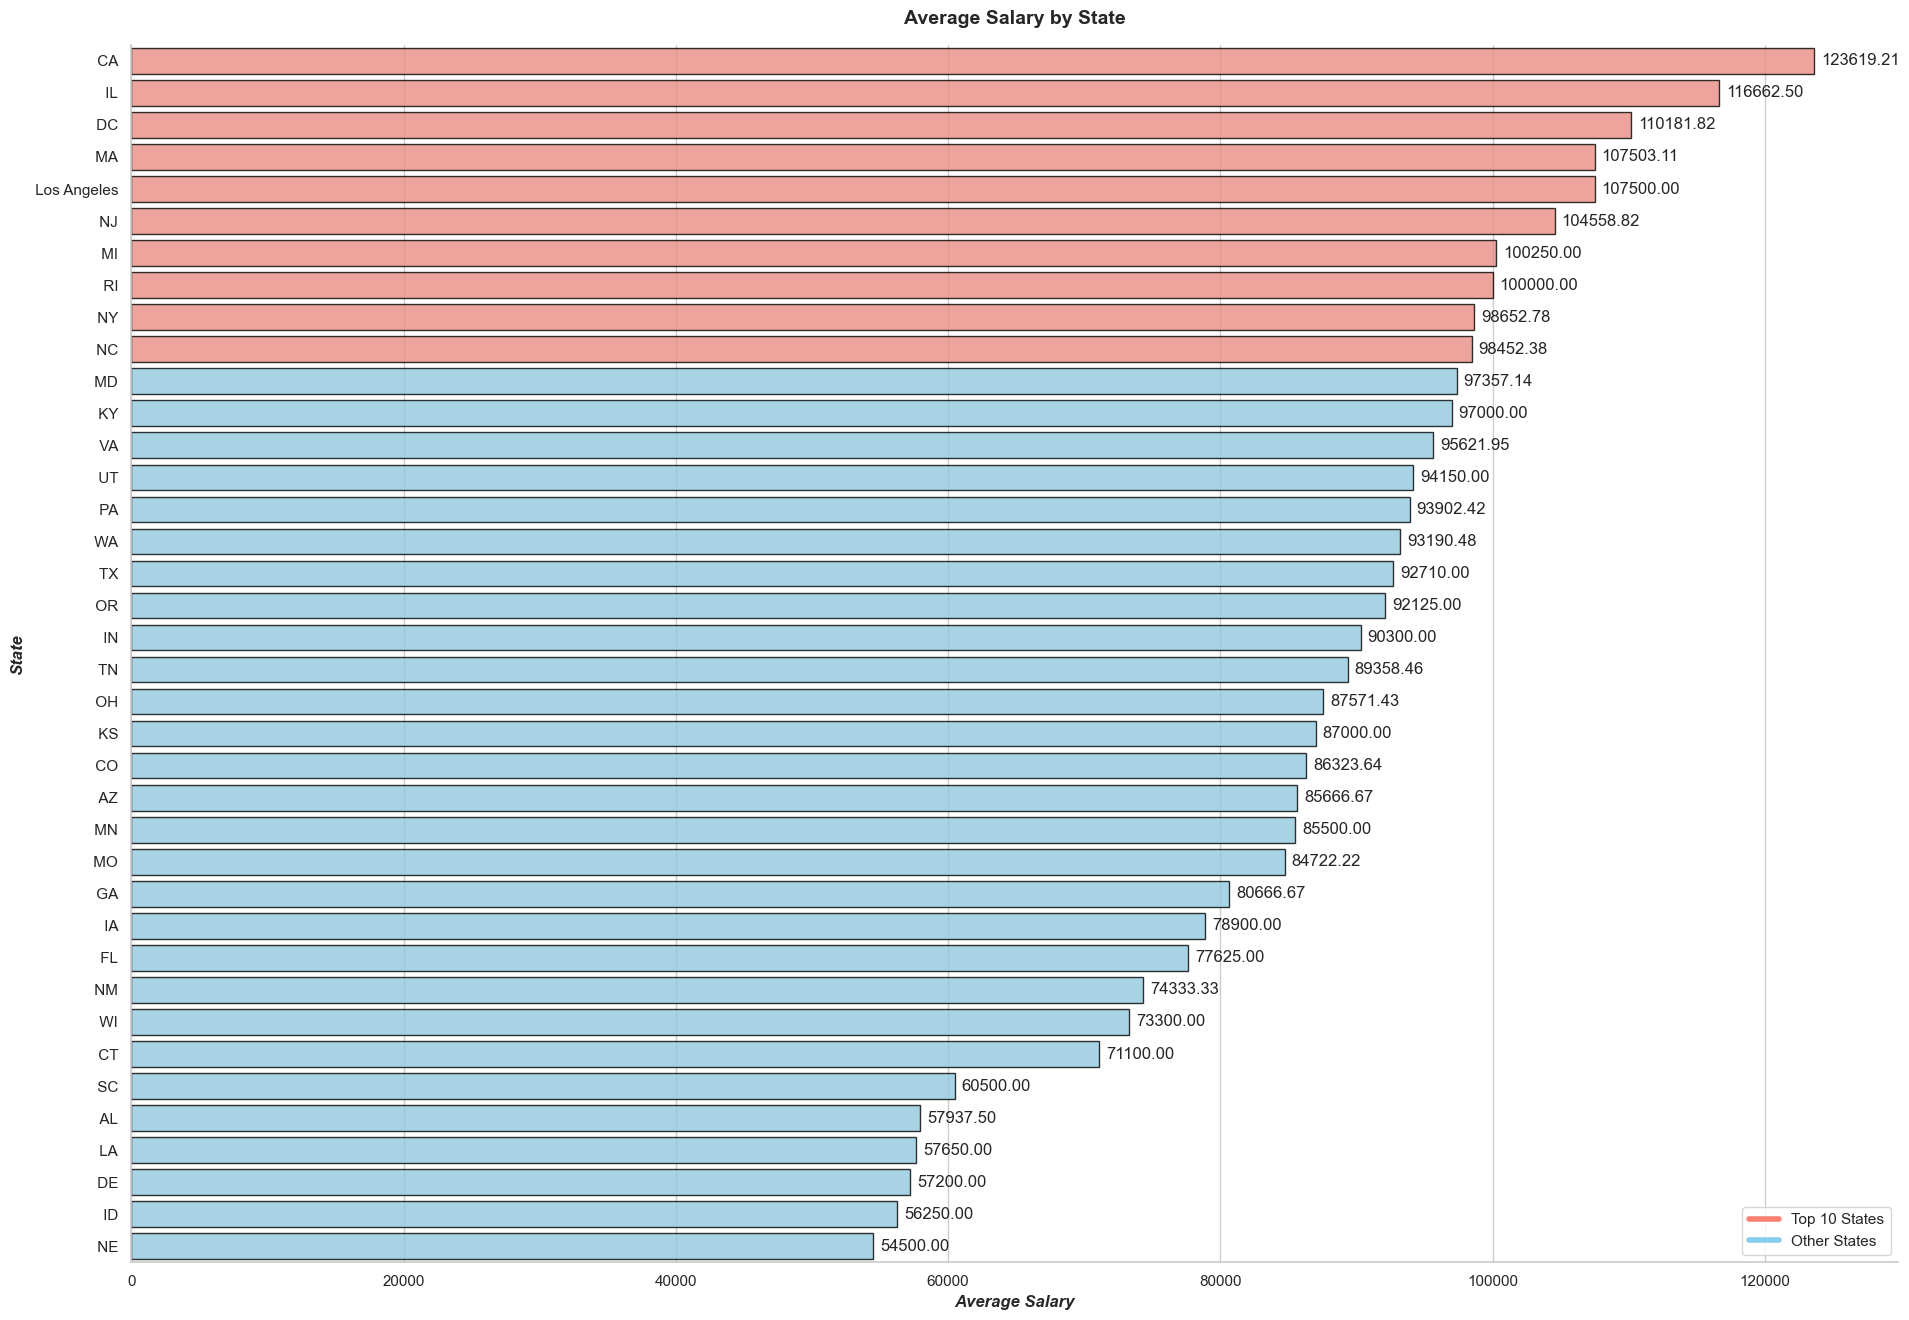

In [20]:
state_salary  = df.groupby('job_state')['Average Salary'].mean().sort_values(ascending=False)
top_10_states = state_salary.head(10).index

plt.figure(figsize=(20, 14))
colors = ['salmon' if state in top_10_states else 'skyblue' for state in state_salary.index]
fg     = sns.barplot(x=state_salary.values, y=state_salary.index, palette=colors, edgecolor='black', alpha=0.8)

plt.title('Average Salary by State', fontdict=font_tit, pad=15)
plt.xlabel('Average Salary', fontdict=font_ax)
plt.ylabel('State', fontdict=font_ax)

for container in fg.containers:
    fg.bar_label(container, fmt='%.2f', label_type='edge', padding=5)

top_patch   = plt.Line2D([0], [0], color='salmon' , lw=4, label='Top 10 States')
other_patch = plt.Line2D([0], [0], color='skyblue', lw=4, label='Other States')
plt.legend(handles=[top_patch, other_patch], loc='lower right')

sns.despine(top=True, right=True)
plt.tight_layout(pad=3)
plt.show()

> **Observations & Summaries**:  
>  
> - California (CA) leads with an average salary of $123,619.21, followed by IL, DC, MA, and NJ—all major tech and financial hubs.  
>  
> - Lowest salaries: Nebraska (NE) ranks last at $54,500, with ID and DE also in the lower range.  
>  
> - Salary disparity: CA’s average is 2.2× higher than NE’s.  
>  
> - Trend: Coastal and economic centers offer higher wages, while inland and Southern states lag behind.  
>  
> - Conclusion: Tech and finance-driven states dominate salary rankings.  

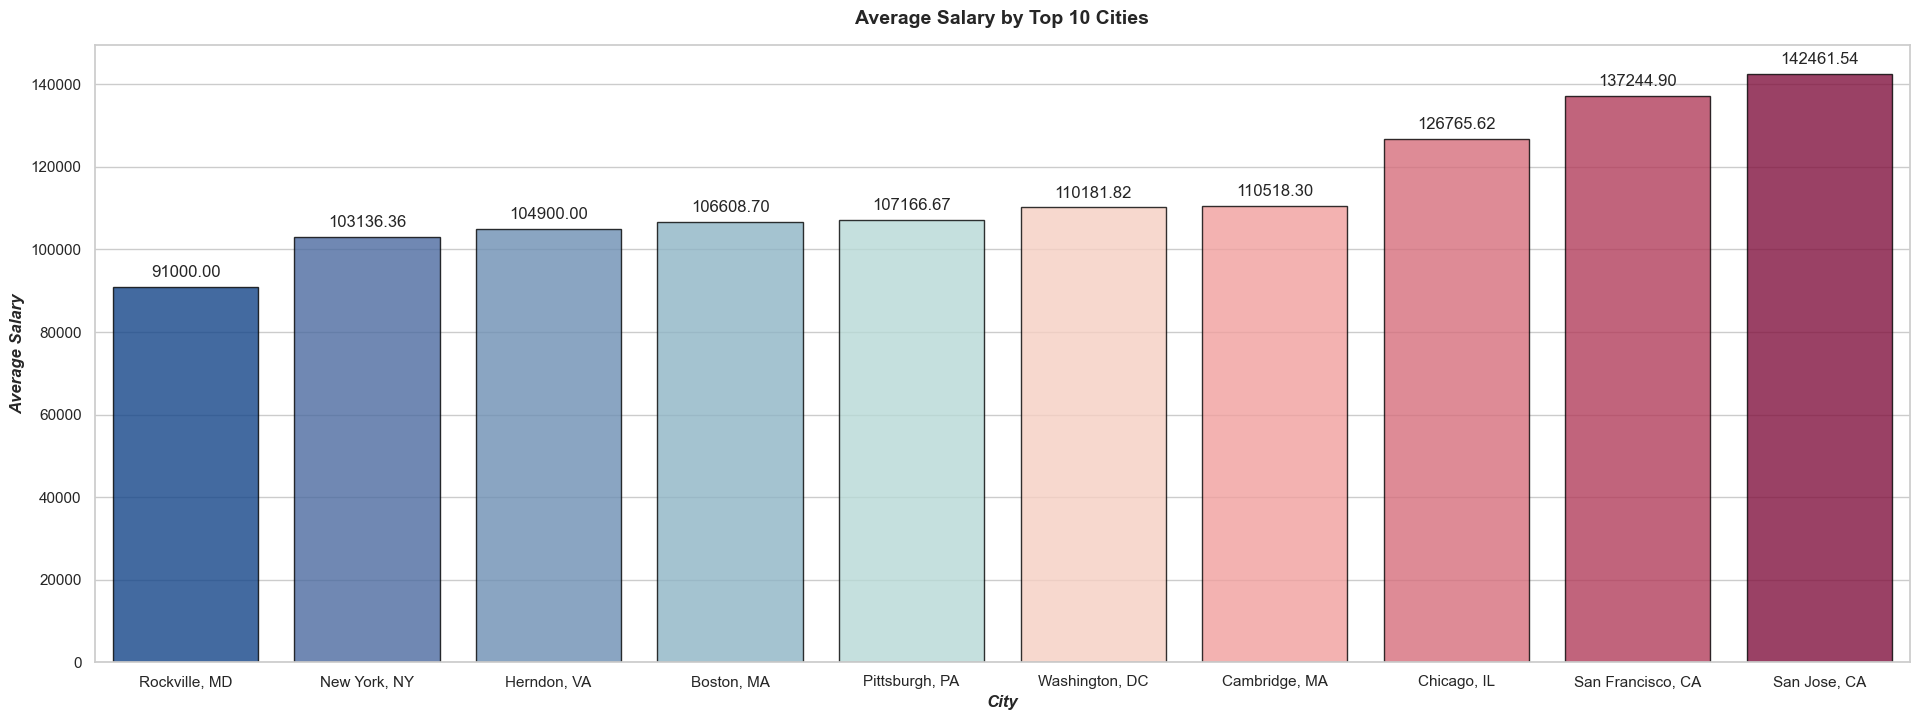

In [21]:
top_cities  = df['Location'].value_counts().head(10).index
city_salary = df[df['Location'].isin(top_cities)].groupby('Location')['Average Salary'].mean().sort_values()

plt.figure(figsize=(20, 8))
fg = sns.barplot(x=city_salary.index, y=city_salary.values, palette=cmap10, edgecolor='black', alpha=0.8)

plt.title('Average Salary by Top 10 Cities', fontdict=font_tit, pad=15)
plt.xlabel('City', fontdict=font_ax)
plt.ylabel('Average Salary', fontdict=font_ax)

for container in fg.containers:
    fg.bar_label(container, fmt='%.2f', label_type='edge', padding=5)

plt.tight_layout(pad=3)
plt.show()

> **Observations & Summaries**:  
>  
> - Highest salaries: San Jose, CA ($142,461.54) and San Francisco, CA ($137,244.90) lead, driven by major tech companies like Google, Apple, and Meta.  
>  
> - Mid-range salaries ($100K–$130K): Chicago, IL, Cambridge, MA, Washington, DC, and Pittsburgh, PA, strong in tech, finance, and education.  
>  
> - Lower-tier salaries (<$100K): New York, NY ($103,136.36), Winston-Salem, NC, and Rockville, MD, with NYC’s lower-than-expected pay linked to income disparity and high living costs.  
>  
> - Salary gap: San Jose’s average is 1.5× higher than Rockville’s ($91,000, lowest among the top 10 cities).  
>  
> - Conclusion: California cities dominate, while lower-paying cities may offer better cost-of-living trade-offs.  

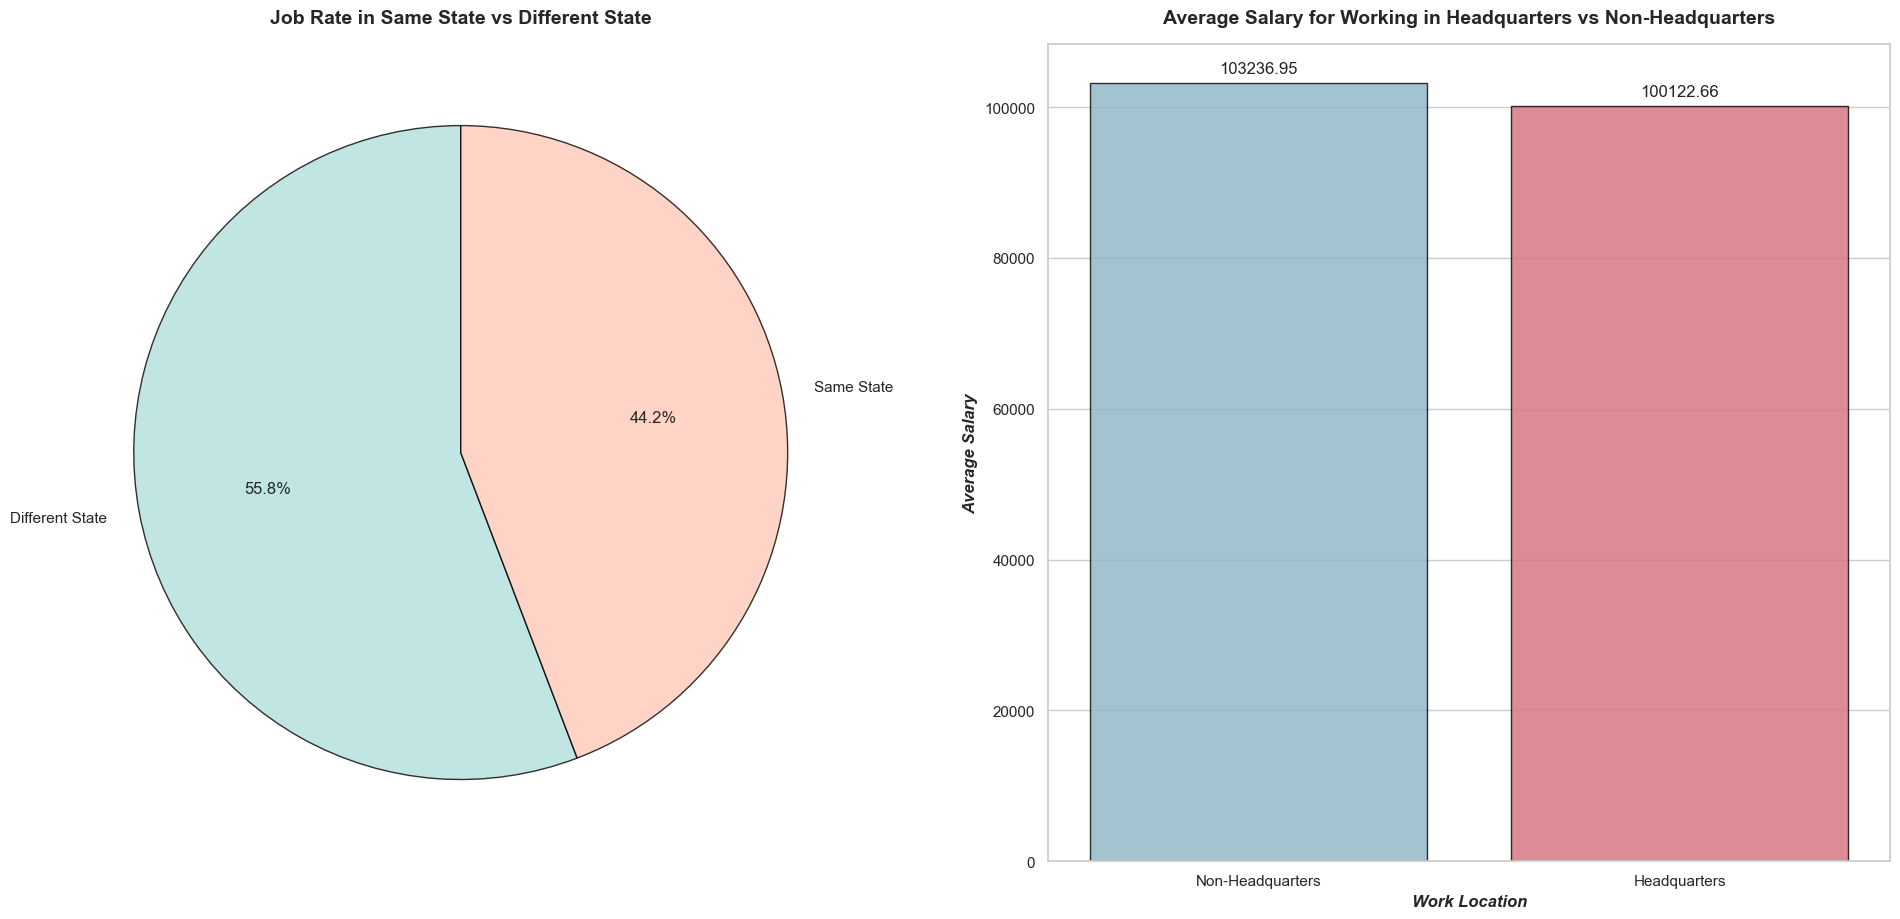

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Pie chart: Job in Same State vs Different State
same_state_counts = df['same_state'].value_counts()

wedges, texts, autotexts = axes[0].pie(same_state_counts, labels=['Different State', 'Same State'],
            autopct='%1.1f%%', startangle=90,
            colors=cmap10[4:6], wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title("Job Rate in Same State vs Different State", fontdict=font_tit, pad=15)

for wedge in wedges:
    wedge.set_alpha(0.8)

# Bar chart: Average salary for working in headquarters vs non-headquarters
df['at_headquarters'] = (df['Location'] == df['Headquarters']).astype(int)
salary_comparison = df.groupby('at_headquarters')['Average Salary'].mean()

sns.barplot(x=salary_comparison.index, y=salary_comparison.values, ax=axes[1],
            palette=[cmap10[3], cmap10[-3]], alpha=0.8, edgecolor='black'
)
axes[1].set_title("Average Salary for Working in Headquarters vs Non-Headquarters", fontdict=font_tit, pad=15)
axes[1].set_xlabel("Work Location", fontdict=font_ax)
axes[1].set_ylabel("Average Salary", fontdict=font_ax)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Non-Headquarters", "Headquarters"])

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', label_type='edge', padding=5)

plt.tight_layout(pad=3)
plt.show()

> **Observations**:  
>  
> Job Distribution (Pie Chart - Left):  
>  
> - Out-of-state jobs dominate (55.8%), driven by remote work and geographic expansion.  
> - In-state jobs (44.2%) are concentrated in roles requiring on-site presence or proximity to headquarters.  
>  
> Average Salary (Bar Chart - Right):  
>  
> - Out-of-state: $103,236.95 (higher).  
> - In-state: $100,122.66 (lower by ~$3,114).  
> - Possible reasons: Cost of living differences across locations & Talent acquisition strategies for remote roles.  

> **Summaries**:  
>  
> - Flexible work arrangements are becoming the norm, with more jobs based out-of-state.  
> - Slight salary advantage for remote roles reflects regional salary adjustments and increased competition for talent. → Work models and salary structures are evolving, adapting to the rise of remote work.  

## **3. Feature Selection**
---

### **3.1. Correlation Matrix**

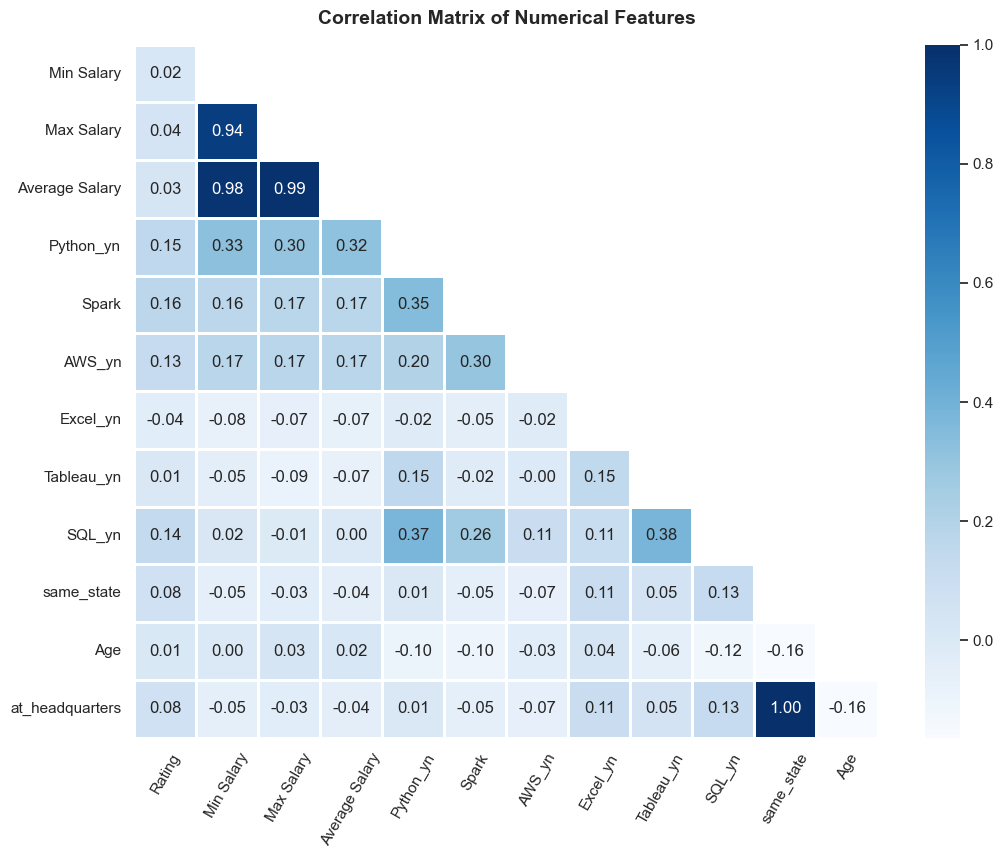

In [23]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numerical_cols].corr().iloc[1:, :-1]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Blues', cbar=True, linewidths=1)
plt.title("Correlation Matrix of Numerical Features", fontdict=font_tit, pad=15)
plt.xticks(rotation=60)

plt.grid(False)
plt.show()

> **Observations & Summaries**:  
>  
> - Salary is primarily driven by Min/Max Salary and technical skills (Python, Spark, AWS).  
>  
> - Python stands out as the most valuable skill for salary growth.  
>  
> - Work location and company age have minimal influence on salary levels.  

### **3.2. ANOVA Analysis**

In [24]:
anova_results = {}
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    groups = [df['Average Salary'][df[col] == group] for group in df[col].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results[col] = {'F-statistic': f_stat, 'p-value': p_value}

anova_results = pd.DataFrame.from_dict(anova_results, orient='index', columns=['F-statistic','p-value','Significance'])
anova_results['Significance'] = anova_results['p-value'] < 0.05
anova_results.sort_values(by='p-value')

,F-statistic,p-value,Significance
Company Name,4.740723,4.549181e-48,True
job_simplified,24.894824,6.405628e-44,True
seniority,43.892767,4.572969e-33,True
Headquarters,3.234980,5.036396e-27,True
Location,2.978916,1.386686e-23,True
job_state,4.248494,9.027568e-15,True
Industry,3.265136,1.173209e-13,True
Type of ownership,7.725791,6.611024e-11,True
Sector,4.283655,7.908559e-11,True
Revenue,5.835820,1.011894e-09,True


> **Observations**:  
>  
> Strongest predictors:  
> - `job_simplified` (F = 24.89, p < 10⁻⁴⁴) → Most influential factor.  
> - `seniority` (F = 42.36, p < 10⁻³²) → Significant impact.  
> - `Company Name` (F = 4.74, p < 10⁻⁴⁸) → Strong influence.  
>  
> Other significant factors:  
> - `Ownership type` (F = 7.73, p < 10⁻¹¹)  
> - `Revenue` (F = 5.84, p < 10⁻⁹)  
> - `Sector` (F = 4.28, p < 10⁻¹¹)  
> - `Job state`, `Headquarters`, `Industry`, `Location`, and `Size` all show notable impact (p < 10⁻⁶).  

> **Summaries**:  
>  
> - **Job role, seniority, and company name** are the strongest salary predictors.  
> - **Ownership, revenue, and industry-related factors** also play a significant role.  
> - **All tested variables influence salary to some extent**, with varying degrees of significance.  

### **3.3. Save features**

In [25]:
data_model = df[['Company Name', 'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'job_simplified', 'seniority', 'Rating Category', 'job_state','Python_yn', 'Spark', 'AWS_yn','Average Salary']]
data_model.to_csv('../data/data_model.csv', index=False)